# Phase 1: Baseline LSTM Surrogate Model

## Architecture Overview

The baseline LSTM model processes the sequential input-output history and produces multi-step delta predictions for all 11 per-CDU output variables.

| Component | Details |
|---|---|
| **Input Projection** | Linear → LayerNorm → ReLU |
| **Encoder** | 2-layer LSTM (128 hidden) with temporal attention pooling |
| **Decoder** | 3-layer MLP (128 → 256 → 128 → output) |
| **Prediction Mode** | Delta (change from last known value) |
| **Normalization** | Z-score (inputs), delta z-score (targets) |
| **History Window** | 1200s (40 steps at 30s subsample) |
| **Prediction Horizon** | 60s (2 steps at 30s subsample) |

### Key Methodological Choices
- **Delta prediction**: predicts change from last observed value, not absolute values
- **Z-score normalization**: preserves signal in narrow-range temperature data
- **Extended history (1200s)**: captures thermal time constants of ~15-25 minutes
- **Output history as input**: provides system state information for conditional dynamics
- **Huber loss (δ=0.5)**: robust to outliers, avoids MSE regression-to-mean

### Training Configuration
- **Optimizer**: AdamW (lr=1e-3, weight_decay=1e-4)
- **Scheduler**: Cosine annealing with warm restarts (T₀=20, T_mult=2)
- **Early stopping**: Patience 20 epochs on validation loss
- **Data split**: 70% train / 15% val / 15% test (temporal, no shuffle)

In [1]:
#  Imports and Device Configuration

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import json
import os
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 16
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-PCIE-16GB
Memory: 16.9 GB


In [2]:
#  Configuration

@dataclass
class LSTMConfig:
    """Configuration for Phase 1: Baseline LSTM."""

    # ── Data ──────────────────────────────────────────────────────────────
    DOI: str = "" # Insert Correct DOI for the dataset
    DATA_NAME: str = "summit_10hrs_operational.parquet"
    NUM_CDUS: int = 257
    CDU_IDS: List[int] = field(default_factory=lambda: list(range(1, 258)))
    TIME_COL: str = 'time'

    # ── Temporal windows ──────────────────────────────────────────────────
    SAMPLING_RATE_SEC: float = 1.0
    SUBSAMPLE_FACTOR: int = 30          # 30s effective resolution
    HISTORY_SECONDS: int = 1200          # 20 min of history (40 steps)
    PREDICTION_SECONDS: int = 30         # 60s ahead (2 steps)

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    @property
    def PREDICTION_STEPS(self) -> int:
        return int(self.PREDICTION_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    # ── Architecture ──────────────────────────────────────────────────────
    HIDDEN_SIZE: int = 128
    NUM_LAYERS: int = 2
    DROPOUT: float = 0.2

    # ── Output groups (all 11 per-CDU outputs predicted jointly) ──────────
    OUTPUT_NAMES: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
        'V_flow_prim_GPM', 'V_flow_sec_GPM',
        'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig',
        'W_flow_CDUP_kW',
    ])

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE: int = 32
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    GRADIENT_CLIP: float = 1.0
    MAX_EPOCHS: int = 150
    PATIENCE: int = 20

    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    TRAIN_RATIO: float = 0.7
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    # ── Column patterns ───────────────────────────────────────────────────
    INPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'Q_flow': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_Q_flow_total',
        'T_Air': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_T_Air',
        'T_ext': 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext',
    })

    OUTPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'T_prim_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_s_C',
        'T_prim_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_r_C',
        'T_sec_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_s_C',
        'T_sec_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_r_C',
        'V_flow_prim_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_prim_GPM',
        'V_flow_sec_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_sec_GPM',
        'p_prim_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_s_psig',
        'p_prim_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_r_psig',
        'p_sec_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_s_psig',
        'p_sec_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_r_psig',
        'W_flow_CDUP_kW': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.W_flow_CDUP_kW',
    })

    # ── Output Categories (from Chapter 5) ────────────────────────────────
    CATEGORY_A: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'p_prim_s_psig', 'p_prim_r_psig',
    ])
    CATEGORY_B: List[str] = field(default_factory=lambda: [
        'T_sec_s_C', 'T_sec_r_C',
    ])
    CATEGORY_C: List[str] = field(default_factory=lambda: [
        'V_flow_prim_GPM',
    ])
    CATEGORY_D: List[str] = field(default_factory=lambda: [
        'p_sec_s_psig', 'p_sec_r_psig',
    ])
    CATEGORY_E: List[str] = field(default_factory=lambda: [
        'V_flow_sec_GPM', 'W_flow_CDUP_kW',
    ])

    def get_category(self, output_type: str) -> str:
        if output_type in self.CATEGORY_A: return 'A (Primary loop)'
        if output_type in self.CATEGORY_B: return 'B (Secondary temp)'
        if output_type in self.CATEGORY_C: return 'C (Primary flow)'
        if output_type in self.CATEGORY_D: return 'D (Secondary pressure)'
        if output_type in self.CATEGORY_E: return 'E (Constant)'
        return 'Unknown'

    def print_config(self):
        n_outputs = len(self.OUTPUT_NAMES) * self.NUM_CDUS
        print("\n" + "=" * 70)
        print("PHASE 1: BASELINE LSTM CONFIGURATION")
        print("=" * 70)
        print(f"History window:       {self.HISTORY_SECONDS}s ({self.HISTORY_STEPS} steps)")
        print(f"Prediction horizon:   {self.PREDICTION_SECONDS}s ({self.PREDICTION_STEPS} steps)")
        print(f"Subsample factor:     {self.SUBSAMPLE_FACTOR}s")
        print(f"CDUs:                 {self.NUM_CDUS} ({self.CDU_IDS})")
        print(f"Output types:         {len(self.OUTPUT_NAMES)}")
        print(f"Total outputs:        {n_outputs}")
        print(f"\nArchitecture:")
        print(f"  LSTM hidden:        {self.HIDDEN_SIZE}")
        print(f"  LSTM layers:        {self.NUM_LAYERS}")
        print(f"  Dropout:            {self.DROPOUT}")
        print(f"\nTraining:")
        print(f"  Loss:               {self.LOSS_TYPE} (δ={self.HUBER_DELTA})")
        print(f"  Learning rate:      {self.LEARNING_RATE}")
        print(f"  Batch size:         {self.BATCH_SIZE}")
        print(f"  Max epochs:         {self.MAX_EPOCHS}")
        print(f"  Patience:           {self.PATIENCE}")
        print("=" * 70)

config = LSTMConfig()
config.print_config()


PHASE 1: BASELINE LSTM CONFIGURATION
History window:       1200s (40 steps)
Prediction horizon:   30s (1 steps)
Subsample factor:     30s
CDUs:                 257 ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 1

In [3]:
#  Normalizer Classes

class ZScoreNormalizer:
    """Z-score (standardization) normalizer."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str]) -> 'ZScoreNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[:, i]
            self.stats[col] = {
                'mean': float(np.nanmean(col_data)),
                'std': float(np.nanstd(col_data) + 1e-8),
            }
        return self

    def transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        normalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            normalized[:, i] = (data[:, i] - s['mean']) / s['std']
        return normalized

    def inverse_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        denormalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            denormalized[:, i] = data[:, i] * s['std'] + s['mean']
        return denormalized


class DeltaNormalizer:
    """Normalizer for delta (change) predictions."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str],
            subsample_factor: int = 1) -> 'DeltaNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[::subsample_factor, i]
            deltas = np.diff(col_data)
            self.stats[col] = {
                'delta_mean': float(np.nanmean(deltas)),
                'delta_std': float(np.nanstd(deltas) + 1e-10),
                'abs_mean': float(np.nanmean(col_data)),
                'abs_std': float(np.nanstd(col_data) + 1e-10),
            }
        return self

    def get_scale(self, col: str) -> float:
        return self.stats[col]['delta_std'] * 10


class LSTMNormalizer:
    """Manages normalizers for LSTM model."""

    def __init__(self, config: LSTMConfig):
        self.config = config
        self.input_normalizer = ZScoreNormalizer()
        self.output_normalizer = ZScoreNormalizer()
        self.delta_normalizer = DeltaNormalizer()

    def fit(self, input_data, output_data, input_cols, output_cols):
        self.input_normalizer.fit(input_data, input_cols)
        self.output_normalizer.fit(output_data, output_cols)
        self.delta_normalizer.fit(output_data, output_cols, self.config.SUBSAMPLE_FACTOR)
        return self

    def inverse_delta(self, predictions, last_data, col_names):
        """Convert normalized deltas back to absolute values."""
        absolute = np.zeros_like(predictions, dtype=np.float32)
        for i, col in enumerate(col_names):
            scale = self.delta_normalizer.get_scale(col)
            denorm_deltas = predictions[:, :, i] * scale
            absolute[:, :, i] = last_data[:, i:i+1] + np.cumsum(denorm_deltas, axis=1)
        return absolute

print("Normalizers defined.")

Normalizers defined.


In [5]:
#  Data Loading & Column Identification

def load_data(config: LSTMConfig) -> pd.DataFrame:
    """Load parquet data from URL with progress bar."""
    import requests
    from tqdm import tqdm
    import io
    
    print(f"Loading data ... ")

    record_id = config.DOI.split("zenodo.")[-1]
    url = f"https://zenodo.org/records/{record_id}/files/{config.DATA_NAME}"
    # Download with progress
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    buffer = io.BytesIO()
    with tqdm(total=total_size, unit='B', unit_scale=True, desc=f"Downloading: {config.DATA_NAME}") as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            buffer.write(chunk)
            pbar.update(len(chunk))
    
    buffer.seek(0)
    df = pd.read_parquet(buffer)
    
    # Sort and print summary
    if config.TIME_COL in df.columns:
        df = df.sort_values(config.TIME_COL).reset_index(drop=True)
        print(f"Loaded data shape: {df.shape}")
        print(f"Time range: {df[config.TIME_COL].min():.1f}s to {df[config.TIME_COL].max():.1f}s")
        print(f"Duration: {(df[config.TIME_COL].max() - df[config.TIME_COL].min()) / 3600:.1f} hours")
    
    return df

def identify_columns(df: pd.DataFrame, config: LSTMConfig) -> Dict:
    """Identify input/output columns and build metadata."""
    result = {
        'input_cols': [],
        'output_cols': [],
        'col_to_cdu': {},
        'col_to_type': {},
    }

    # Input columns (per-CDU)
    for cdu_id in config.CDU_IDS:
        for pattern_name, pattern in config.INPUT_PATTERNS.items():
            if pattern_name == 'T_ext':
                continue
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['input_cols'].append(col)

    # T_ext (global)
    t_ext_pattern = config.INPUT_PATTERNS.get('T_ext', '')
    if t_ext_pattern in df.columns:
        result['input_cols'].append(t_ext_pattern)
    else:
        for c in df.columns:
            if 't_ext' in c.lower() and c not in result['input_cols']:
                result['input_cols'].append(c)
                break

    # Output columns
    for output_name in config.OUTPUT_NAMES:
        pattern = config.OUTPUT_PATTERNS[output_name]
        for cdu_id in config.CDU_IDS:
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['output_cols'].append(col)
                result['col_to_cdu'][col] = cdu_id
                result['col_to_type'][col] = output_name

    result['input_cols'] = list(dict.fromkeys(result['input_cols']))
    result['output_cols'] = list(dict.fromkeys(result['output_cols']))

    print(f"\n{'='*60}")
    print("COLUMN IDENTIFICATION")
    print(f"{'='*60}")
    print(f"Input columns:     {len(result['input_cols'])}")
    print(f"Output columns:    {len(result['output_cols'])}")
    print(f"  Per CDU:         {len(config.OUTPUT_NAMES)}")
    print(f"  CDUs:            {config.NUM_CDUS}")

    return result


df = load_data(config)
column_info = identify_columns(df, config)

Loading data ... 


Downloading: summit_10hrs_operational.parquet: 100%|██████████| 2.07G/2.07G [01:47<00:00, 19.3MB/s] 


Loaded data shape: (36000, 6430)
Time range: 2394.1s to 5994.0s
Duration: 1.0 hours

COLUMN IDENTIFICATION
Input columns:     515
Output columns:    2827
  Per CDU:         11
  CDUs:            257


In [6]:
#  Dataset

class LSTMDataset(Dataset):
    """
    Dataset for LSTM surrogate model.
    
    Provides:
    - Concatenated input + output history as model input
    - Normalized delta targets for prediction
    - Last observed output for absolute reconstruction
    """

    def __init__(
        self,
        input_data: np.ndarray,
        output_data: np.ndarray,
        config: LSTMConfig,
        normalizer: LSTMNormalizer,
        column_info: Dict,
    ):
        self.config = config
        self.column_info = column_info
        self.normalizer = normalizer

        # Subsample
        self.input_data = input_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)
        self.output_data = output_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)

        # Normalize
        self.input_normalized = normalizer.input_normalizer.transform(
            self.input_data, column_info['input_cols']
        )
        self.output_normalized = normalizer.output_normalizer.transform(
            self.output_data, column_info['output_cols']
        )

        total_required = config.HISTORY_STEPS + config.PREDICTION_STEPS
        self.n_samples = max(0, len(self.input_data) - total_required)

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        H = self.config.HISTORY_STEPS
        K = self.config.PREDICTION_STEPS
        input_end = idx + H
        output_start = input_end
        output_end = output_start + K

        # Concatenated input + output history
        u_hist = self.input_normalized[idx:input_end]       # (H, n_inputs)
        y_hist = self.output_normalized[idx:input_end]       # (H, n_outputs)
        x = np.concatenate([u_hist, y_hist], axis=1)         # (H, n_inputs + n_outputs)

        # Delta targets
        last_output = self.output_data[input_end - 1]        # (n_outputs,)
        future_output = self.output_data[output_start:output_end]  # (K, n_outputs)

        output_cols = self.column_info['output_cols']
        y_delta = np.zeros_like(future_output)
        for i, col in enumerate(output_cols):
            scale = self.normalizer.delta_normalizer.get_scale(col)
            y_delta[:, i] = (future_output[:, i] - last_output[i]) / scale

        return {
            'x': torch.from_numpy(x).float(),
            'y': torch.from_numpy(y_delta).float(),
            'last_output': torch.from_numpy(last_output).float(),
            'future_output': torch.from_numpy(future_output).float(),
        }

print("LSTMDataset defined.")

LSTMDataset defined.


In [7]:
#  Create Data Loaders

def create_dataloaders(
    df: pd.DataFrame,
    column_info: Dict,
    config: LSTMConfig,
) -> Tuple[DataLoader, DataLoader, DataLoader, LSTMNormalizer]:
    """Create train/val/test dataloaders with contiguous time splits."""

    input_cols = column_info['input_cols']
    output_cols = column_info['output_cols']

    input_data = df[input_cols].values.astype(np.float32)
    output_data = df[output_cols].values.astype(np.float32)

    # Contiguous time-based split (no temporal leakage)
    n_total = len(input_data)
    train_end = int(n_total * config.TRAIN_RATIO)
    val_end = int(n_total * (config.TRAIN_RATIO + config.VAL_RATIO))

    print(f"\nData split (contiguous temporal):")
    print(f"  Train: 0 → {train_end:,} ({train_end/n_total:.0%})")
    print(f"  Val:   {train_end:,} → {val_end:,} ({(val_end-train_end)/n_total:.0%})")
    print(f"  Test:  {val_end:,} → {n_total:,} ({(n_total-val_end)/n_total:.0%})")

    # Fit normalizers on training data only
    normalizer = LSTMNormalizer(config)
    normalizer.fit(input_data[:train_end], output_data[:train_end],
                   input_cols, output_cols)

    # Create datasets
    splits = [
        ('Train', 0, train_end),
        ('Val', train_end, val_end),
        ('Test', val_end, n_total),
    ]

    datasets = []
    for name, start, end in splits:
        ds = LSTMDataset(
            input_data[start:end],
            output_data[start:end],
            config, normalizer, column_info,
        )
        print(f"  {name} dataset: {len(ds)} samples")
        datasets.append(ds)

    train_loader = DataLoader(
        datasets[0], batch_size=config.BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    )
    val_loader = DataLoader(
        datasets[1], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        datasets[2], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    print(f"\nDataLoader sizes:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches:   {len(val_loader)}")
    print(f"  Test batches:  {len(test_loader)}")

    return train_loader, val_loader, test_loader, normalizer


train_loader, val_loader, test_loader, normalizer = create_dataloaders(
    df, column_info, config
)

# Verify shapes
sample_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  X (input):       {sample_batch['x'].shape}")
print(f"  Y (target):      {sample_batch['y'].shape}")
print(f"  Last output:     {sample_batch['last_output'].shape}")


Data split (contiguous temporal):
  Train: 0 → 25,200 (70%)
  Val:   25,200 → 30,600 (15%)
  Test:  30,600 → 36,000 (15%)
  Train dataset: 799 samples
  Val dataset: 139 samples
  Test dataset: 139 samples

DataLoader sizes:
  Train batches: 24
  Val batches:   5
  Test batches:  5

Batch shapes:
  X (input):       torch.Size([32, 40, 3342])
  Y (target):      torch.Size([32, 1, 2827])
  Last output:     torch.Size([32, 2827])


## Model Architecture

```
Input: (B, H=40, n_inputs + n_outputs)
  │
  ├── Input Projection: Linear → LayerNorm → ReLU → Dropout
  │     (n_inputs + n_outputs) → 128
  │
  ├── LSTM Encoder: 2-layer LSTM (128 hidden)
  │     → LayerNorm
  │
  ├── Temporal Attention:
  │     Linear(128→64) → Tanh → Linear(64→1) → Softmax
  │     Weighted sum over time steps → context (128)
  │
  └── Decoder MLP:
        Linear(128→256) → LayerNorm → ReLU → Dropout
        Linear(256→128) → ReLU → Dropout
        Linear(128 → n_outputs × K)
        Reshape → (B, K, n_outputs)
```

In [8]:
#  LSTM Model Definition

class BaselineLSTM(nn.Module):
    """
    Phase 1 Baseline LSTM with temporal attention.
    
    Architecture:
    1. Input projection: maps concatenated features to hidden dimension
    2. LSTM encoder: 2-layer LSTM captures temporal dependencies
    3. Temporal attention: learned weighted average over time steps
    4. Decoder MLP: projects to delta predictions for each future step
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout: float = 0.2,
        prediction_steps: int = 2,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.prediction_steps = prediction_steps

        # Input projection with layer norm
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # LSTM encoder
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.lstm_norm = nn.LayerNorm(hidden_size)

        # Temporal attention
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )

        # Decoder MLP
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.LayerNorm(hidden_size * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size * prediction_steps),
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, seq_len, input_size)
        Returns:
            (batch, prediction_steps, output_size)
        """
        batch_size = x.shape[0]

        # Project input
        x = self.input_proj(x)                    # (B, H, hidden)

        # LSTM
        lstm_out, _ = self.lstm(x)                # (B, H, hidden)
        lstm_out = self.lstm_norm(lstm_out)

        # Attention over time steps
        attn_weights = self.attention(lstm_out)    # (B, H, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(lstm_out * attn_weights, dim=1)  # (B, hidden)

        # Decode
        out = self.decoder(context)               # (B, output_size * pred_steps)
        out = out.view(batch_size, self.prediction_steps, self.output_size)

        return out


# Instantiate model
n_inputs = len(column_info['input_cols'])
n_outputs = len(column_info['output_cols'])
total_input_size = n_inputs + n_outputs  # concatenated input + output history

model = BaselineLSTM(
    input_size=total_input_size,
    output_size=n_outputs,
    hidden_size=config.HIDDEN_SIZE,
    num_layers=config.NUM_LAYERS,
    dropout=config.DROPOUT,
    prediction_steps=config.PREDICTION_STEPS,
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{'='*60}")
print("MODEL SUMMARY")
print(f"{'='*60}")
print(f"Total parameters:  {total_params:,}")
print(f"Input size:        {total_input_size} ({n_inputs} inputs + {n_outputs} output history)")
print(f"Output size:       {n_outputs}")
print(f"Prediction steps:  {config.PREDICTION_STEPS}")
print(f"Hidden size:       {config.HIDDEN_SIZE}")
print(f"LSTM layers:       {config.NUM_LAYERS}")
print(model)


MODEL SUMMARY
Total parameters:  1,132,044
Input size:        3342 (515 inputs + 2827 output history)
Output size:       2827
Prediction steps:  1
Hidden size:       128
LSTM layers:       2
BaselineLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=3342, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (lstm_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5):

In [9]:
#  Training Utilities

class EarlyStopping:
    """Early stopping with best model checkpoint."""

    def __init__(self, patience: int = 20, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def load_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_epoch(model, loader, criterion, optimizer, config, device):
    """Single training epoch."""
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in loader:
        x = batch['x'].to(device, non_blocking=True)
        y = batch['y'].to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)

        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validate on loader."""
    model.eval()
    total_loss = 0
    n_batches = 0

    for batch in loader:
        x = batch['x'].to(device, non_blocking=True)
        y = batch['y'].to(device, non_blocking=True)

        pred = model(x)
        loss = criterion(pred, y)

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)

print("Training utilities defined.")

Training utilities defined.


## Training

In [10]:
#  Training Loop

criterion = nn.HuberLoss(delta=config.HUBER_DELTA)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
early_stopping = EarlyStopping(patience=config.PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'lr': []}

print("\n" + "=" * 70)
print("TRAINING — Phase 1: Baseline LSTM")
print("=" * 70)

train_start_time = time.time()

pbar = tqdm(range(config.MAX_EPOCHS), desc="Training")
for epoch in pbar:
    train_loss = train_epoch(model, train_loader, criterion, optimizer, config, DEVICE)
    val_loss = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    pbar.set_postfix({
        'train': f'{train_loss:.5f}',
        'val': f'{val_loss:.5f}',
        'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
    })

    if early_stopping(val_loss, model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

early_stopping.load_best(model)
train_time = time.time() - train_start_time
n_epochs_trained = len(history['train_loss'])

print(f"\nTraining complete.")
print(f"  Epochs trained:       {n_epochs_trained}")
print(f"  Best validation loss: {early_stopping.best_loss:.6f}")
print(f"  Training time:        {train_time:.1f}s ({train_time/60:.1f} min)")


TRAINING — Phase 1: Baseline LSTM


Training:   0%|          | 0/150 [00:00<?, ?it/s]


Early stopping at epoch 25

Training complete.
  Epochs trained:       25
  Best validation loss: 0.004395
  Training time:        51.5s (0.9 min)


## Training Details

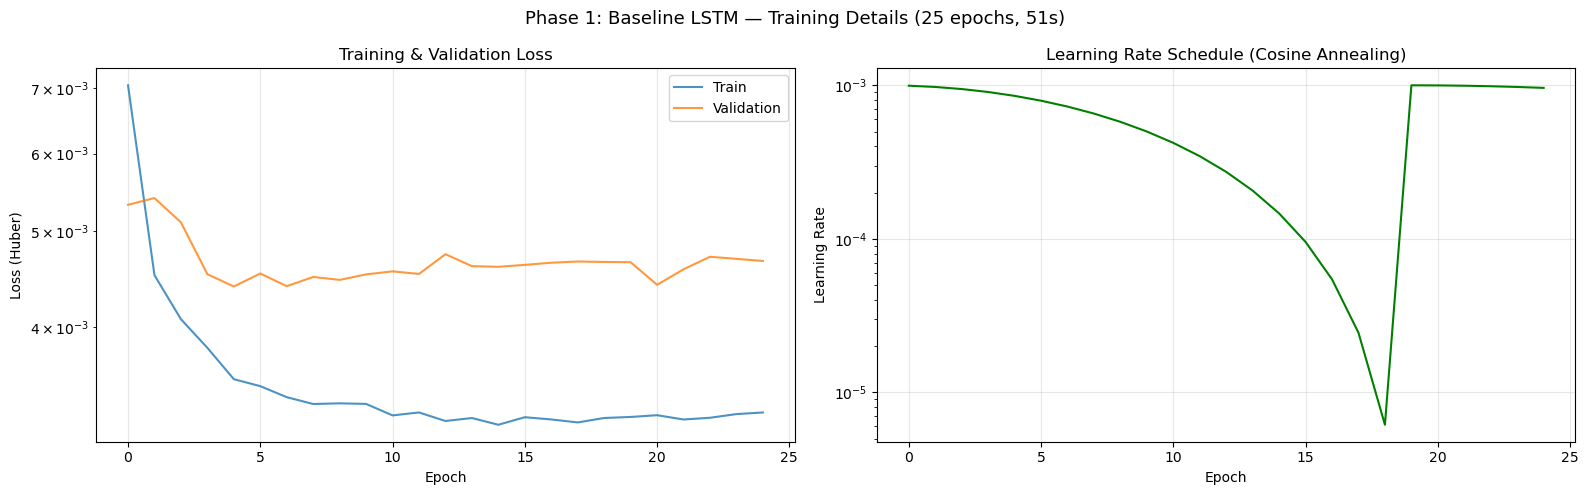


Training Summary:
  Final train loss: 0.003273
  Final val loss:   0.004666
  Best val loss:    0.004395
  Val/Train ratio:  1.43


In [11]:
#  Training Loss Curves

import os
os.makedirs('phase_1_vis', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train', linewidth=1.5, alpha=0.8)
axes[0].plot(history['val_loss'], label='Validation', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Huber)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Learning rate schedule
axes[1].plot(history['lr'], linewidth=1.5, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule (Cosine Annealing)')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.suptitle(f'Phase 1: Baseline LSTM — Training Details ({n_epochs_trained} epochs, {train_time:.0f}s)', 
             fontsize=13)
plt.tight_layout()
plt.savefig('phase_1_vis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining Summary:")
print(f"  Final train loss: {history['train_loss'][-1]:.6f}")
print(f"  Final val loss:   {history['val_loss'][-1]:.6f}")
print(f"  Best val loss:    {early_stopping.best_loss:.6f}")
print(f"  Val/Train ratio:  {history['val_loss'][-1] / (history['train_loss'][-1] + 1e-10):.2f}")

## Evaluation on Test Set

### Performance Metrics (from Chapter 3)

**Primary Accuracy Measures:**
- MAE, RMSE, R², Variance Ratio, Correlation Coefficient

**Delta Prediction Metrics:**
- Delta Std Ratio, Cumulative Drift Error

**Comparison Metrics:**
- Persistence R², Skill Score, Beats Persistence flag

**Computational Performance:**
- Training time, epochs, model parameters, inference time

In [12]:
#  Collect Predictions

@torch.no_grad()
def collect_predictions(model, loader, config, normalizer, column_info, device):
    """Run model on full loader and collect predictions + targets in absolute space."""
    model.eval()
    all_preds, all_targets, all_last_out, all_future = [], [], [], []

    for batch in tqdm(loader, desc="Collecting predictions", leave=False):
        x = batch['x'].to(device, non_blocking=True)
        pred = model(x)  # (B, K, n_outputs)

        all_preds.append(pred.cpu().numpy())
        all_targets.append(batch['y'].numpy())
        all_last_out.append(batch['last_output'].numpy())
        all_future.append(batch['future_output'].numpy())

    pred_norm = np.concatenate(all_preds)
    last_out = np.concatenate(all_last_out)
    future_out = np.concatenate(all_future)

    # Convert normalized deltas → absolute values
    output_cols = column_info['output_cols']
    pred_absolute = normalizer.inverse_delta(pred_norm, last_out, output_cols)

    return {
        'pred_absolute': pred_absolute,
        'target_absolute': future_out,
        'pred_normalized': pred_norm,
        'target_normalized': np.concatenate(all_targets),
        'last_output': last_out,
    }


# Measure inference time
print("\nCollecting test predictions...")
inference_start = time.time()
predictions_dict = collect_predictions(
    model, test_loader, config, normalizer, column_info, DEVICE,
)
inference_time = time.time() - inference_start

n_test_samples = predictions_dict['pred_absolute'].shape[0]
print(f"Predictions shape: {predictions_dict['pred_absolute'].shape}")
print(f"  = ({n_test_samples} test samples, {config.PREDICTION_STEPS} steps, {n_outputs} outputs)")
print(f"Inference time: {inference_time:.2f}s ({inference_time/n_test_samples*1000:.2f} ms/sample)")

Predictions shape: (139, 1, 2827)
  = (139 test samples, 1 steps, 2827 outputs)
Inference time: 0.98s (7.02 ms/sample)


In [ ]:
#  Compute Comprehensive Metrics

def compute_metrics(predictions_dict, column_info, config):
    """
    Compute per-output metrics matching the evaluation criteria from Chapter 3.
    
    Primary: MAE, RMSE, R², Variance Ratio, Correlation
    Delta: Delta Std Ratio, Cumulative Drift Error
    Comparison: Persistence R², Skill Score
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    pred_norm = predictions_dict['pred_normalized']
    target_norm = predictions_dict['target_normalized']
    output_cols = column_info['output_cols']
    K = config.PREDICTION_STEPS

    results = []
    for i, col in enumerate(output_cols):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()

        # === Primary Accuracy Measures ===
        mae = np.mean(np.abs(p - t))
        rmse = np.sqrt(np.mean((p - t) ** 2))

        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        var_pred = np.var(p)
        var_true = np.var(t)
        variance_ratio = var_pred / (var_true + 1e-10)

        if np.std(p) > 1e-10 and np.std(t) > 1e-10:
            correlation = np.corrcoef(p, t)[0, 1]
        else:
            correlation = 0.0

        # === Delta Prediction Metrics ===
        pred_deltas = pred_norm[:, :, i].flatten()
        target_deltas = target_norm[:, :, i].flatten()
        delta_std_ratio = np.std(pred_deltas) / (np.std(target_deltas) + 1e-10)

        # Cumulative drift: error at last prediction step vs first
        if K > 1:
            drift_error = np.mean(np.abs(pred[:, -1, i] - target[:, -1, i])) - \
                          np.mean(np.abs(pred[:, 0, i] - target[:, 0, i]))
        else:
            drift_error = 0.0

        # === Persistence Baseline ===
        last_val = last_out[:, i]
        persistence = np.repeat(last_val[:, np.newaxis], K, axis=1).flatten()
        ss_res_pers = np.sum((t - persistence) ** 2)
        r2_pers = 1 - ss_res_pers / (ss_tot + 1e-10)
        skill_score = (r2 - r2_pers) / (1 - r2_pers + 1e-10)

        # Per-step R²
        step_r2 = []
        for k in range(K):
            pk = pred[:, k, i]
            tk = target[:, k, i]
            ss_res_k = np.sum((tk - pk) ** 2)
            ss_tot_k = np.sum((tk - tk.mean()) ** 2)
            step_r2.append(1 - ss_res_k / (ss_tot_k + 1e-10))

        cdu_id = column_info['col_to_cdu'].get(col, 'Unknown')
        output_type = column_info['col_to_type'].get(col, 'Unknown')
        category = config.get_category(output_type)

        results.append({
            'Output': col,
            'CDU': cdu_id,
            'Type': output_type,
            'Category': category,
            # Primary accuracy
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'Variance_Ratio': variance_ratio,
            'Correlation': correlation,
            # Delta metrics
            'Delta_Std_Ratio': delta_std_ratio,
            'Cumulative_Drift': drift_error,
            # Persistence comparison
            'Persistence_R²': r2_pers,
            'Beats_Persistence': r2 > r2_pers,
            'Skill_Score': skill_score,
            # Per-step
            **{f'R²_step{k+1}': step_r2[k] for k in range(K)},
        })

    return pd.DataFrame(results)


metrics_df = compute_metrics(predictions_dict, column_info, config)
print(f"Metrics computed for {len(metrics_df)} outputs.")

In [14]:
#  Results Summary — Overall & Per-Category

print("\n" + "=" * 70)
print("RESULTS SUMMARY — Phase 1: Baseline LSTM")
print("=" * 70)

# Overall metrics
print(f"\n--- All {len(metrics_df)} Outputs ---")
print(f"  Mean R²:           {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:         {metrics_df['R²'].median():.4f}")
print(f"  Min R²:            {metrics_df['R²'].min():.4f}")
print(f"  Max R²:            {metrics_df['R²'].max():.4f}")
print(f"  Std R²:            {metrics_df['R²'].std():.4f}")
print(f"  Mean Variance Ratio: {metrics_df['Variance_Ratio'].mean():.4f}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)} "
      f"({metrics_df['Beats_Persistence'].mean():.1%})")
print(f"  Mean Skill Score:  {metrics_df['Skill_Score'].mean():.4f}")

# Per-category summary
print(f"\n--- Per-Category Performance ---")
cat_summary = metrics_df.groupby('Category').agg({
    'R²': ['mean', 'median', 'min', 'max', 'count'],
    'RMSE': 'mean',
    'Variance_Ratio': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(cat_summary.to_string())

# Per output-type summary
print(f"\n--- Per Output Type ---")
type_summary = metrics_df.groupby('Type').agg({
    'R²': ['mean', 'median', 'min', 'max'],
    'RMSE': 'mean',
    'MAE': 'mean',
    'Variance_Ratio': 'mean',
    'Correlation': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(type_summary.to_string())

# R² distribution
print(f"\n--- R² Distribution ---")
thresholds = [0.99, 0.95, 0.90, 0.80, 0.50, 0.0]
labels = ['≥ 0.99', '≥ 0.95', '≥ 0.90', '≥ 0.80', '≥ 0.50', '≥ 0.00']
for threshold, label in zip(thresholds, labels):
    count = (metrics_df['R²'] >= threshold).sum()
    print(f"  R² {label}: {count}/{len(metrics_df)} ({count/len(metrics_df):.1%})")
count_neg = (metrics_df['R²'] < 0).sum()
print(f"  R² < 0.00: {count_neg}/{len(metrics_df)} ({count_neg/len(metrics_df):.1%})")

# Computational summary
print(f"\n--- Computational Performance ---")
print(f"  Model Parameters:     {total_params:,}")
print(f"  Training Epochs:      {n_epochs_trained}")
print(f"  Training Time:        {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"  Inference Time (total): {inference_time:.2f}s")
print(f"  Inference Time (per sample): {inference_time/n_test_samples*1000:.2f} ms")


RESULTS SUMMARY — Phase 1: Baseline LSTM

--- All 2827 Outputs ---
  Mean R²:           0.8336
  Median R²:         0.9979
  Min R²:            -1.0487
  Max R²:            1.0000
  Std R²:            0.3716
  Mean Variance Ratio: 1.0026
  Beats Persistence: 1531/2827 (54.2%)
  Mean Skill Score:  0.0416

--- Per-Category Performance ---
                            R²                                  RMSE Variance_Ratio Beats_Persistence
                          mean  median     min     max count    mean           mean              mean
Category                                                                                             
A (Primary loop)        0.9994  0.9998  0.9053  1.0000  1028  0.0005         1.0020            0.8667
B (Secondary temp)      0.9871  0.9968  0.7532  0.9998   514  0.0074         1.0019            0.3385
C (Primary flow)        0.9974  0.9991  0.9733  0.9999   257  0.0000         1.0033            0.6887
D (Secondary pressure)  0.6771  0.8360 -0.5116  

## Evaluation Metric Visualizations

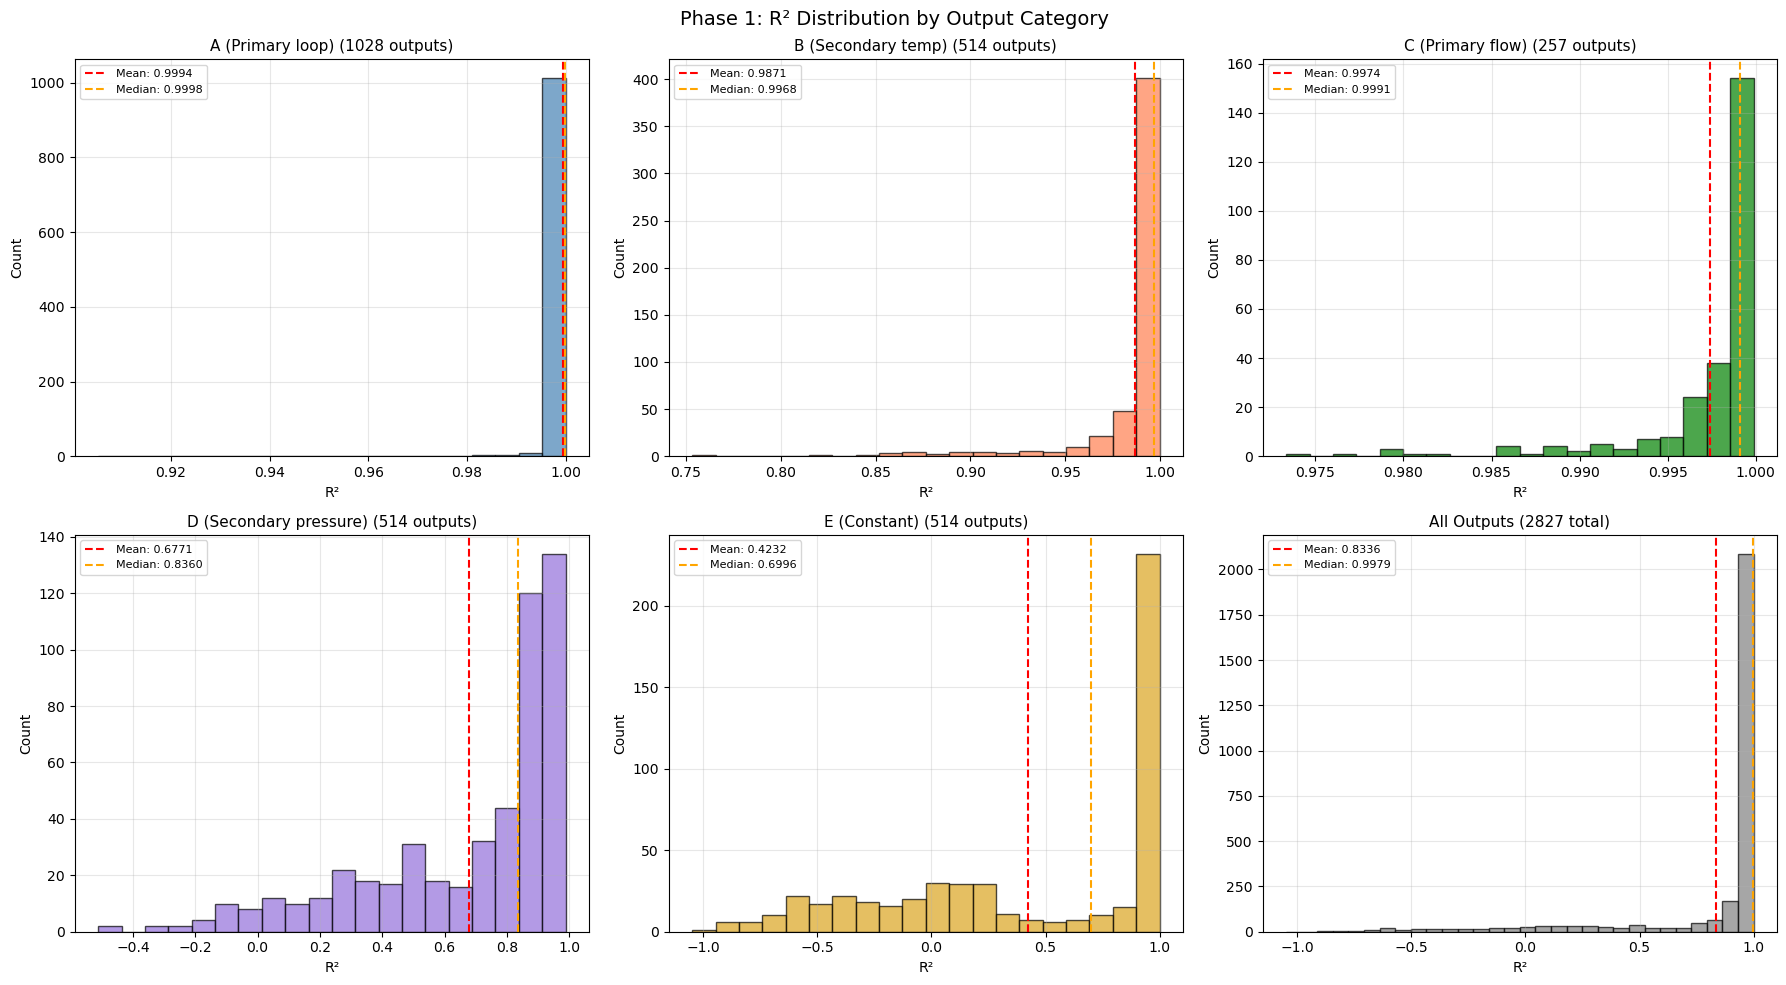

In [15]:
#  Visualization 1 — R² Distribution by Category

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

categories = ['A (Primary loop)', 'B (Secondary temp)', 'C (Primary flow)',
              'D (Secondary pressure)', 'E (Constant)']
colors = ['steelblue', 'coral', 'green', 'mediumpurple', 'goldenrod']

for idx, (cat, color) in enumerate(zip(categories, colors)):
    ax = axes[idx]
    cat_data = metrics_df[metrics_df['Category'] == cat]['R²']
    if len(cat_data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(cat_data, bins=min(20, len(cat_data)), alpha=0.7,
            edgecolor='black', color=color)
    ax.axvline(cat_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {cat_data.mean():.4f}')
    ax.axvline(cat_data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {cat_data.median():.4f}')
    ax.set_title(f'{cat} ({len(cat_data)} outputs)', fontsize=11)
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Overall in last subplot
ax = axes[5]
ax.hist(metrics_df['R²'], bins=30, alpha=0.7, edgecolor='black', color='gray')
ax.axvline(metrics_df['R²'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {metrics_df["R²"].mean():.4f}')
ax.axvline(metrics_df['R²'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {metrics_df["R²"].median():.4f}')
ax.set_title(f'All Outputs ({len(metrics_df)} total)', fontsize=11)
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 1: R² Distribution by Output Category', fontsize=14)
plt.tight_layout()
plt.savefig('phase_1_vis/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

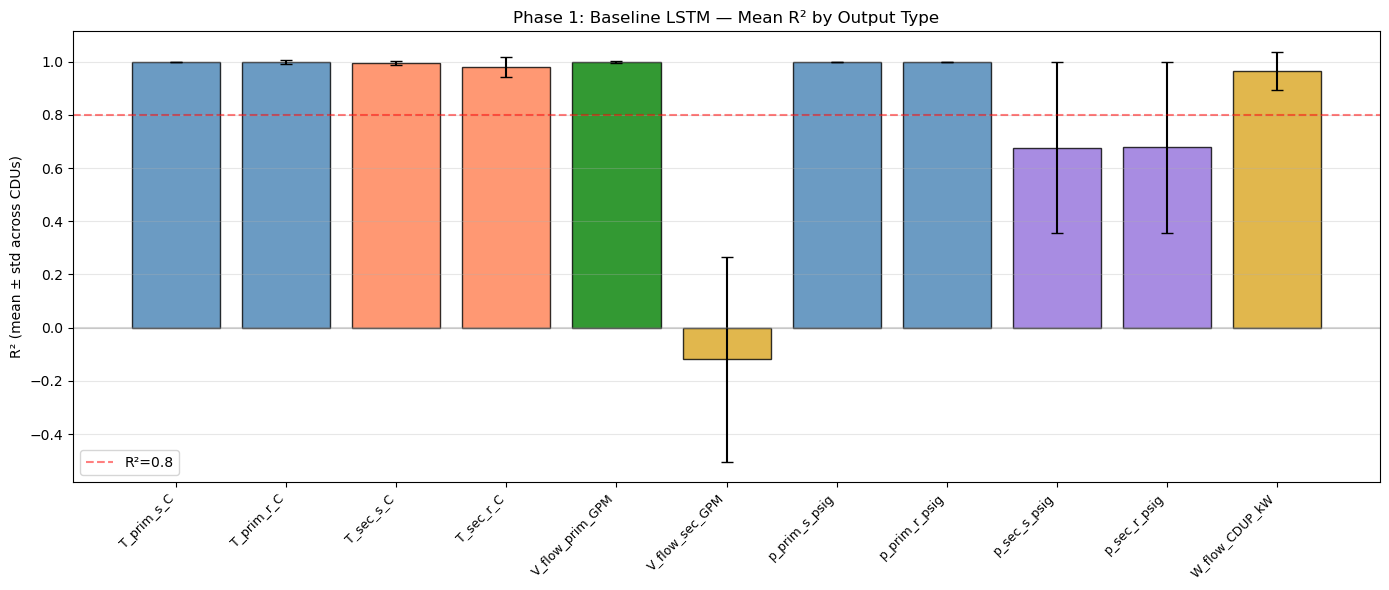

In [16]:
#  Visualization 2 — Per-Output-Type R² Bar Chart

output_types = metrics_df['Type'].unique()
type_means = metrics_df.groupby('Type')['R²'].agg(['mean', 'std']).reindex(output_types)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(output_types))
bars = ax.bar(x, type_means['mean'], yerr=type_means['std'], capsize=4,
              color='steelblue', alpha=0.8, edgecolor='black')

# Color bars by category
for i, otype in enumerate(output_types):
    cat = config.get_category(otype)
    color_map = {
        'A (Primary loop)': 'steelblue',
        'B (Secondary temp)': 'coral',
        'C (Primary flow)': 'green',
        'D (Secondary pressure)': 'mediumpurple',
        'E (Constant)': 'goldenrod',
    }
    bars[i].set_facecolor(color_map.get(cat, 'gray'))

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² (mean ± std across CDUs)')
ax.set_title('Phase 1: Baseline LSTM — Mean R² by Output Type')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8')
ax.axhline(y=0.0, color='gray', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_1_vis/r2_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

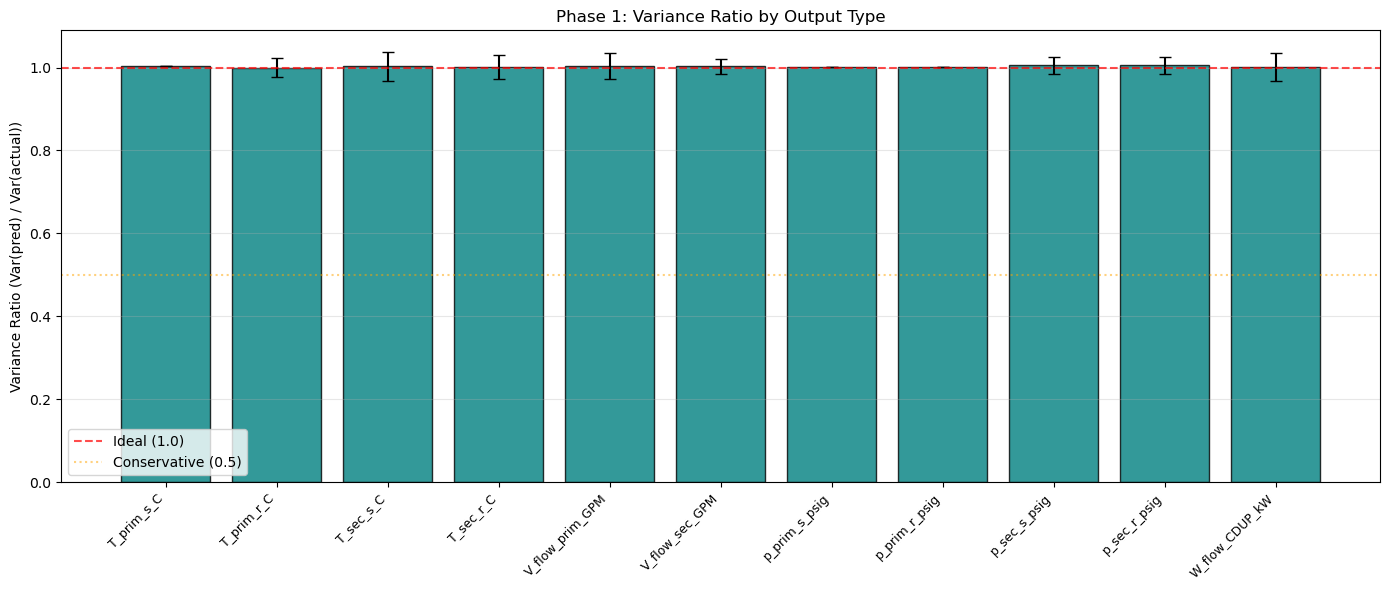

In [17]:
#  Visualization 3 — Variance Ratio by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_var = metrics_df.groupby('Type')['Variance_Ratio'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_var['mean'], yerr=type_var['std'], capsize=4,
              color='teal', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Variance Ratio (Var(pred) / Var(actual))')
ax.set_title('Phase 1: Variance Ratio by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Ideal (1.0)')
ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='Conservative (0.5)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_1_vis/variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

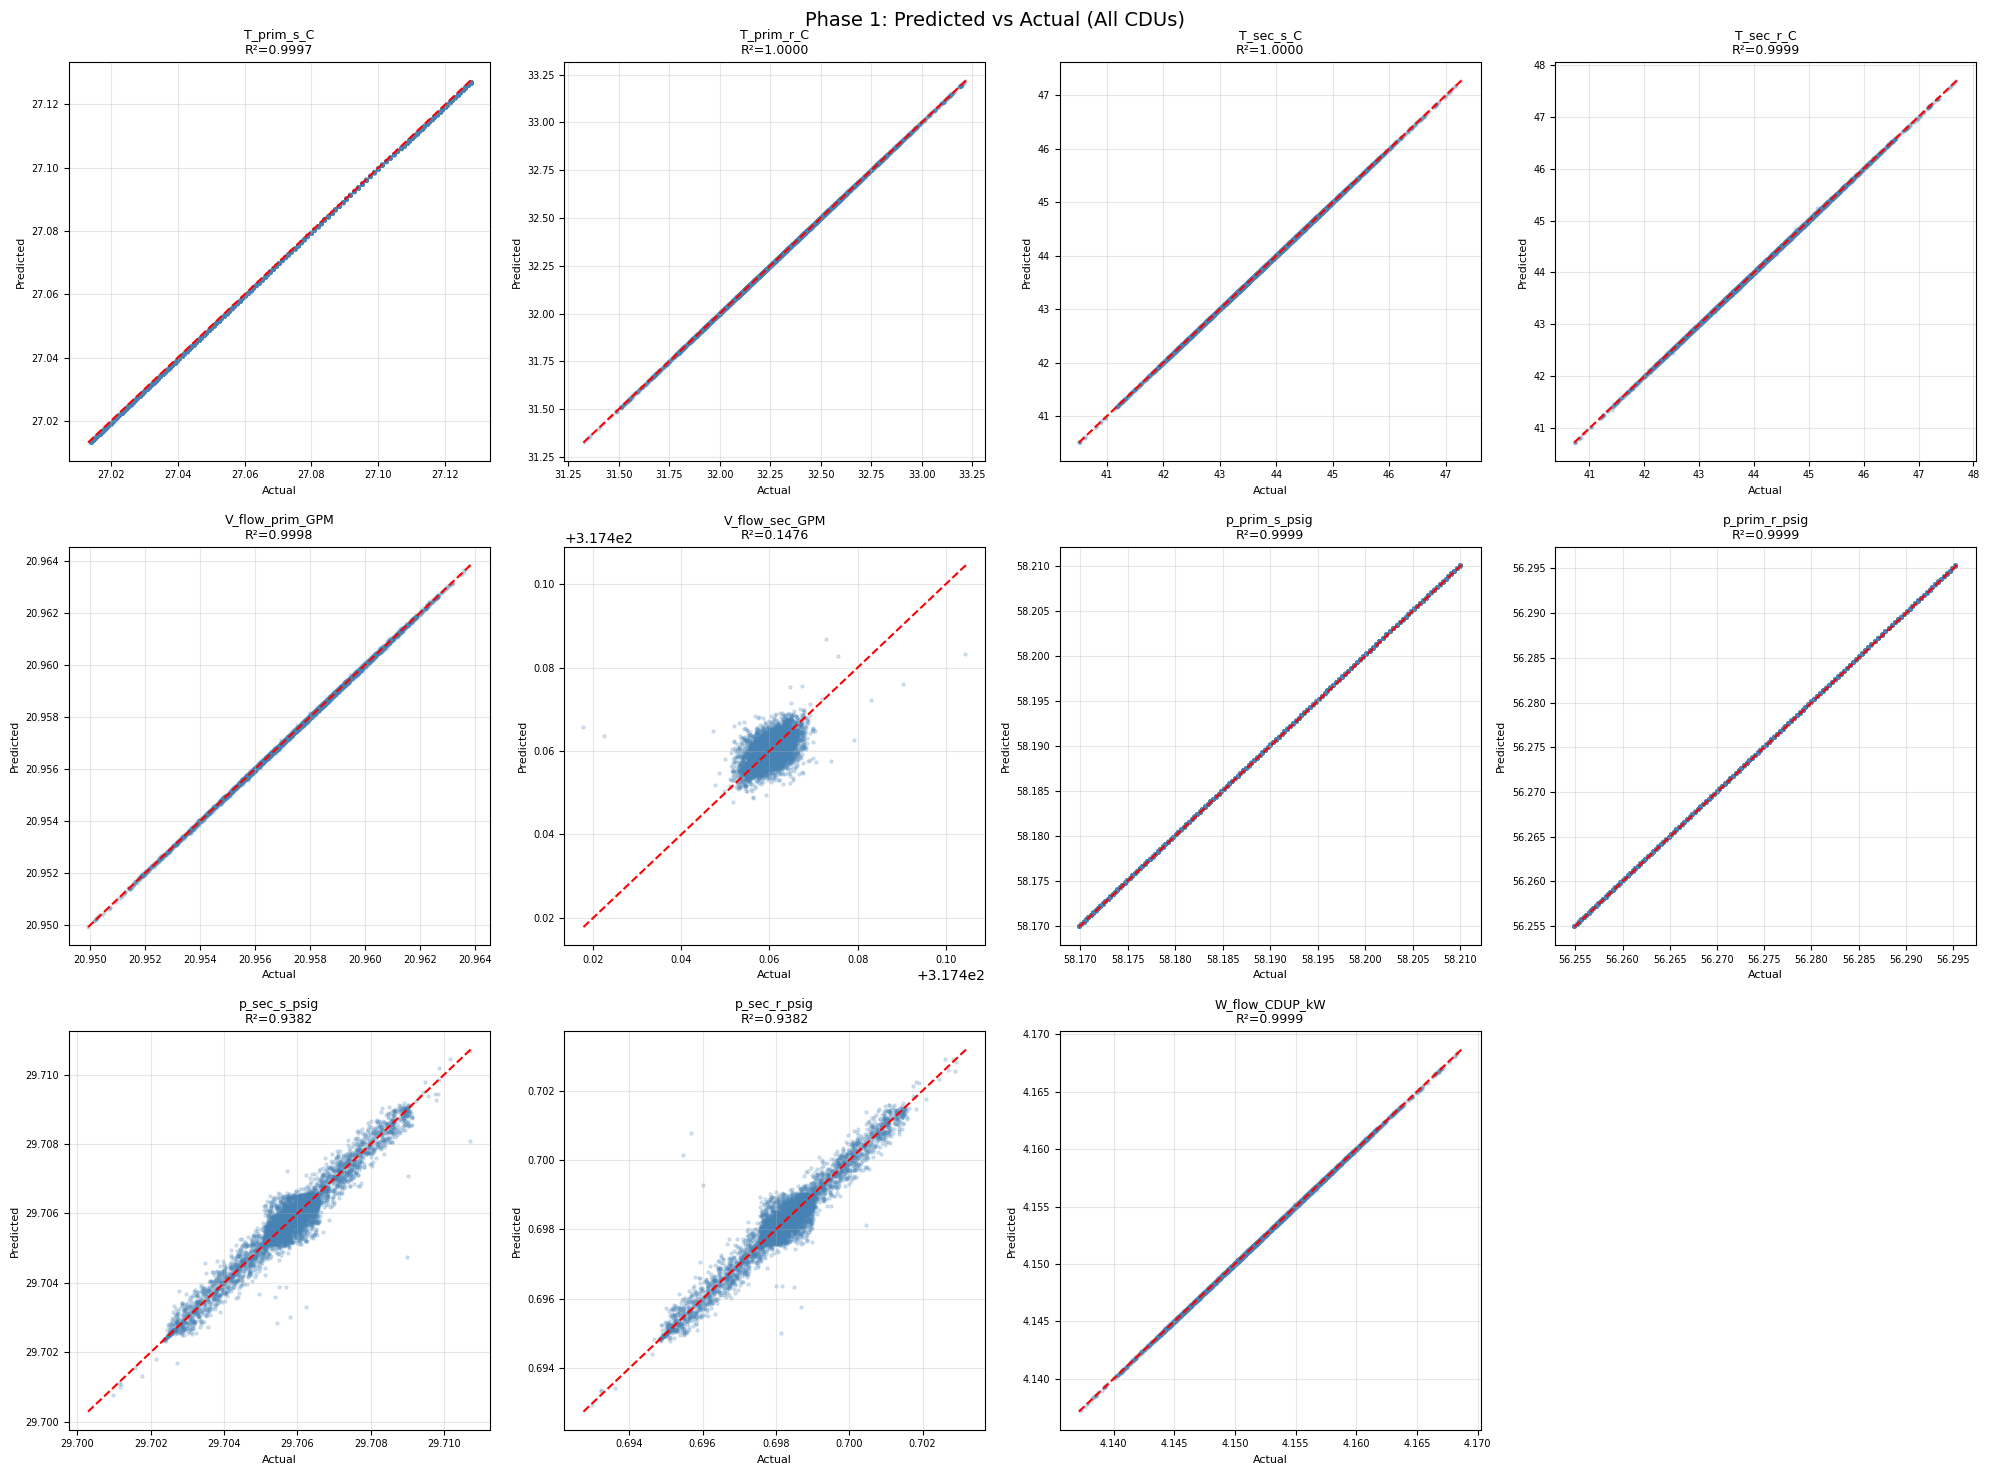

In [18]:
#  Visualization 4 — Scatter Plots (Predicted vs Actual) per Output Type

output_types_list = config.OUTPUT_NAMES
n_types = len(output_types_list)
pred = predictions_dict['pred_absolute']
target = predictions_dict['target_absolute']

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, output_type in enumerate(output_types_list):
    if idx >= len(axes):
        break
    ax = axes[idx]

    # Collect all CDU data for this output type
    all_pred, all_target = [], []
    for col_idx, col in enumerate(column_info['output_cols']):
        if column_info['col_to_type'].get(col) == output_type:
            all_pred.append(pred[:, :, col_idx].flatten())
            all_target.append(target[:, :, col_idx].flatten())

    if len(all_pred) == 0:
        ax.set_visible(False)
        continue

    all_pred = np.concatenate(all_pred)
    all_target = np.concatenate(all_target)

    # Subsample for plotting
    n_plot = min(5000, len(all_pred))
    plot_idx = np.random.choice(len(all_pred), n_plot, replace=False)

    ax.scatter(all_target[plot_idx], all_pred[plot_idx], alpha=0.2, s=5, c='steelblue')

    # Perfect prediction line
    vmin = min(all_target.min(), all_pred.min())
    vmax = max(all_target.max(), all_pred.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.5)

    # R²
    ss_res = np.sum((all_target - all_pred) ** 2)
    ss_tot = np.sum((all_target - all_target.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-10)

    ax.set_title(f'{output_type}\nR²={r2:.4f}', fontsize=9)
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(output_types_list), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 1: Predicted vs Actual (All CDUs)', fontsize=14)
plt.tight_layout()
plt.savefig('phase_1_vis/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

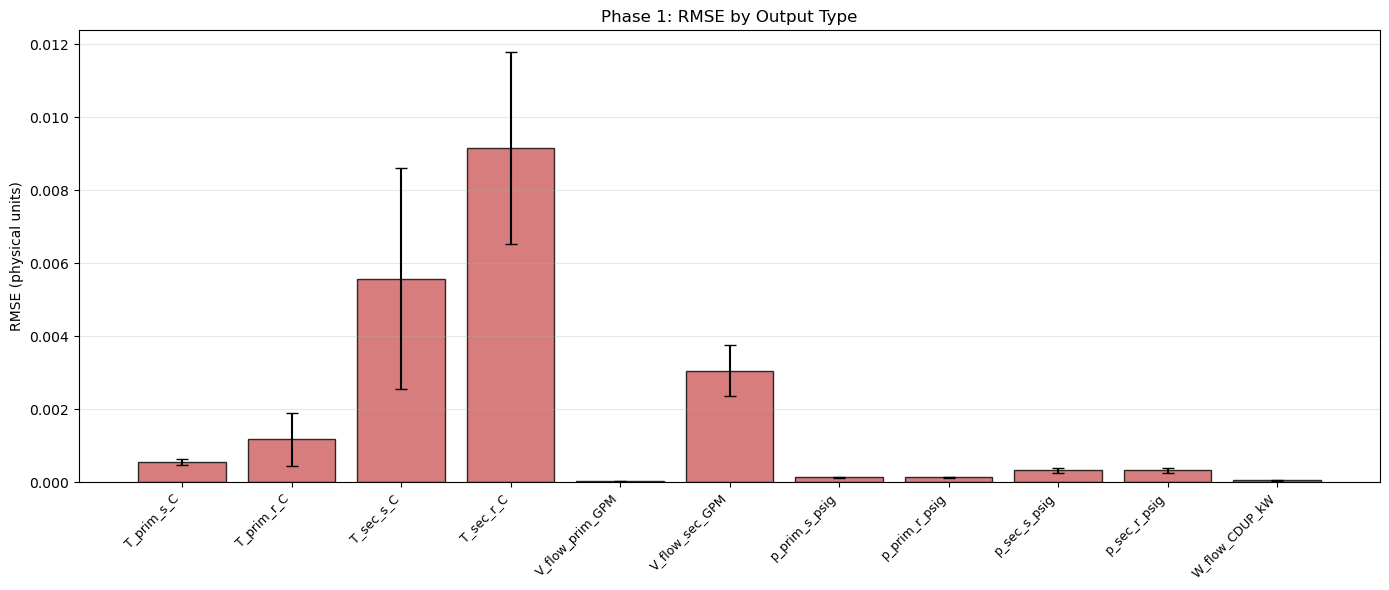

In [19]:
#  Visualization 5 — RMSE by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_rmse = metrics_df.groupby('Type')['RMSE'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_rmse['mean'], yerr=type_rmse['std'], capsize=4,
              color='indianred', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSE (physical units)')
ax.set_title('Phase 1: RMSE by Output Type')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_1_vis/rmse_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

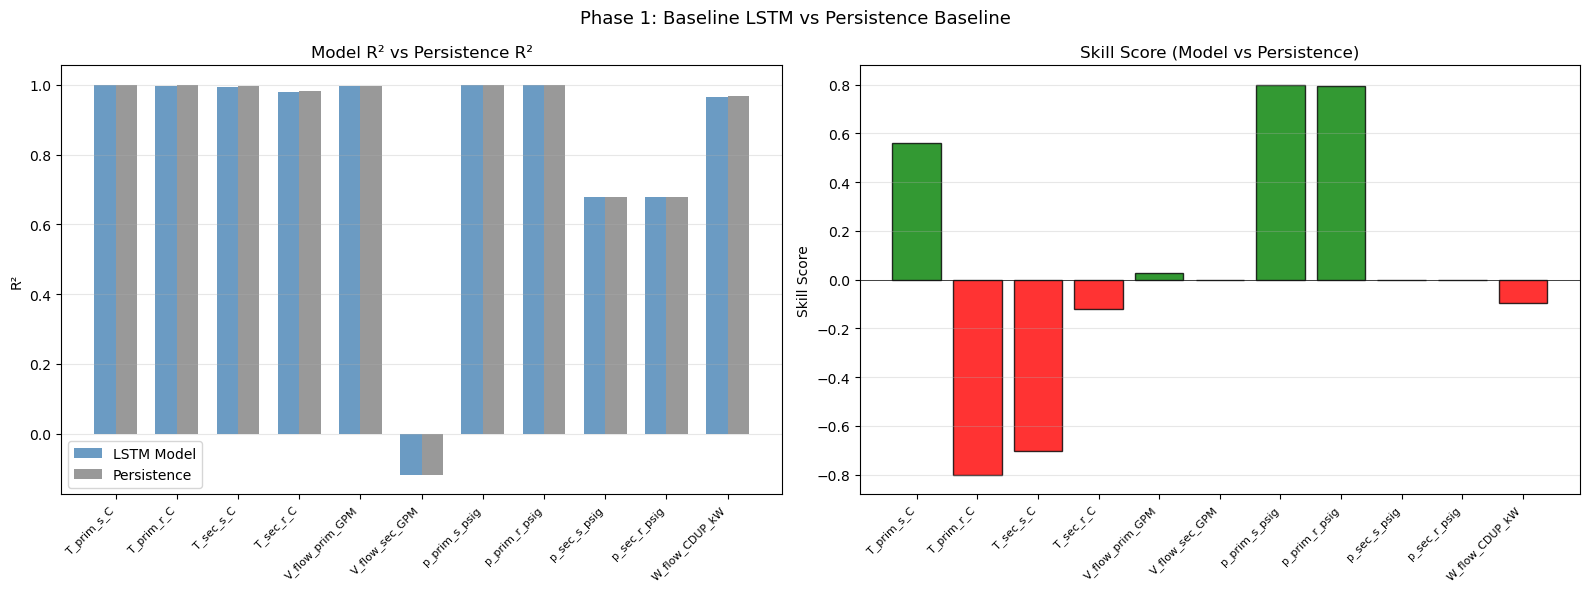

In [20]:
#  Visualization 6 — Model vs Persistence Comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
ax = axes[0]
model_r2 = metrics_df.groupby('Type')['R²'].mean().reindex(output_types)
persist_r2 = metrics_df.groupby('Type')['Persistence_R²'].mean().reindex(output_types)

x = np.arange(len(output_types))
width = 0.35
ax.bar(x - width/2, model_r2, width, label='LSTM Model', color='steelblue', alpha=0.8)
ax.bar(x + width/2, persist_r2, width, label='Persistence', color='gray', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('Model R² vs Persistence R²')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Skill score
ax = axes[1]
skill = metrics_df.groupby('Type')['Skill_Score'].mean().reindex(output_types)
colors_skill = ['green' if s > 0 else 'red' for s in skill]
ax.bar(x, skill, color=colors_skill, alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Skill Score')
ax.set_title('Skill Score (Model vs Persistence)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 1: Baseline LSTM vs Persistence Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('phase_1_vis/persistence.png', dpi=150, bbox_inches='tight')
plt.show()

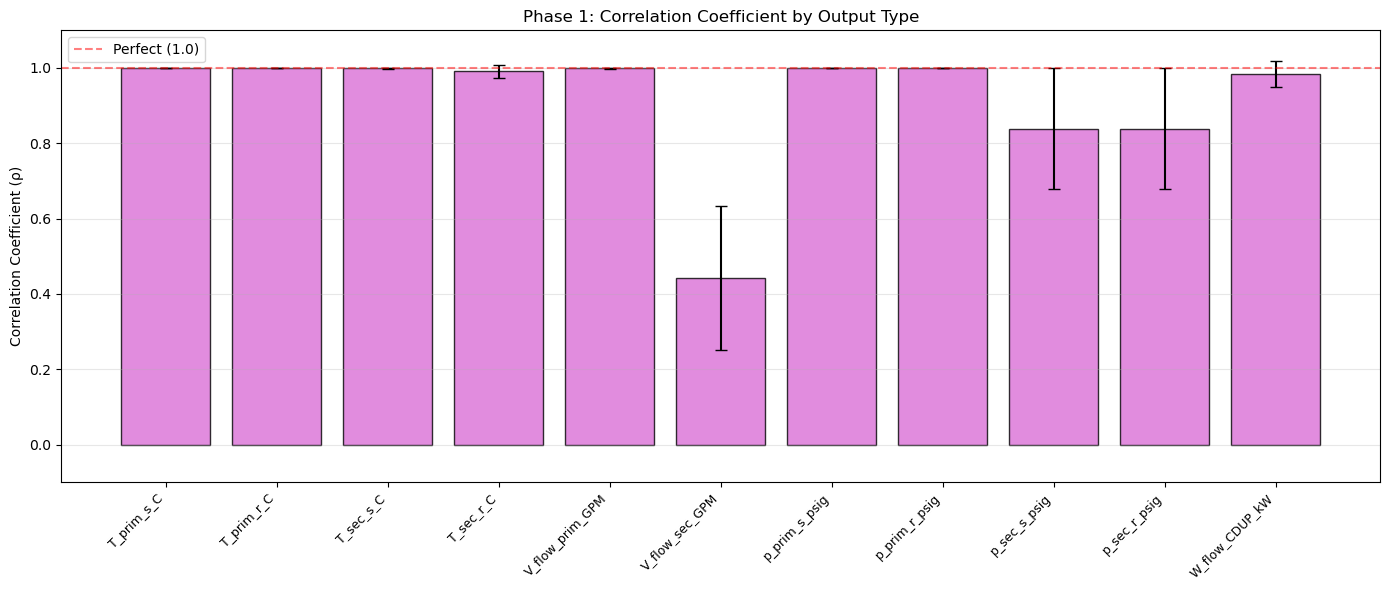

In [21]:
#  Visualization 7 — Correlation Coefficient by Output Type

fig, ax = plt.subplots(figsize=(14, 6))
type_corr = metrics_df.groupby('Type')['Correlation'].agg(['mean', 'std']).reindex(output_types)

x = np.arange(len(output_types))
bars = ax.bar(x, type_corr['mean'], yerr=type_corr['std'], capsize=4,
              color='orchid', alpha=0.8, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Correlation Coefficient (ρ)')
ax.set_title('Phase 1: Correlation Coefficient by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (1.0)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('phase_1_vis/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Time-Series Predictions (300-second sample)

For each output type and CDU, we show a 300-second window comparing:
- **Actual** (ground truth) values
- **Model prediction** (LSTM)
- **Persistence baseline** (last observed value)

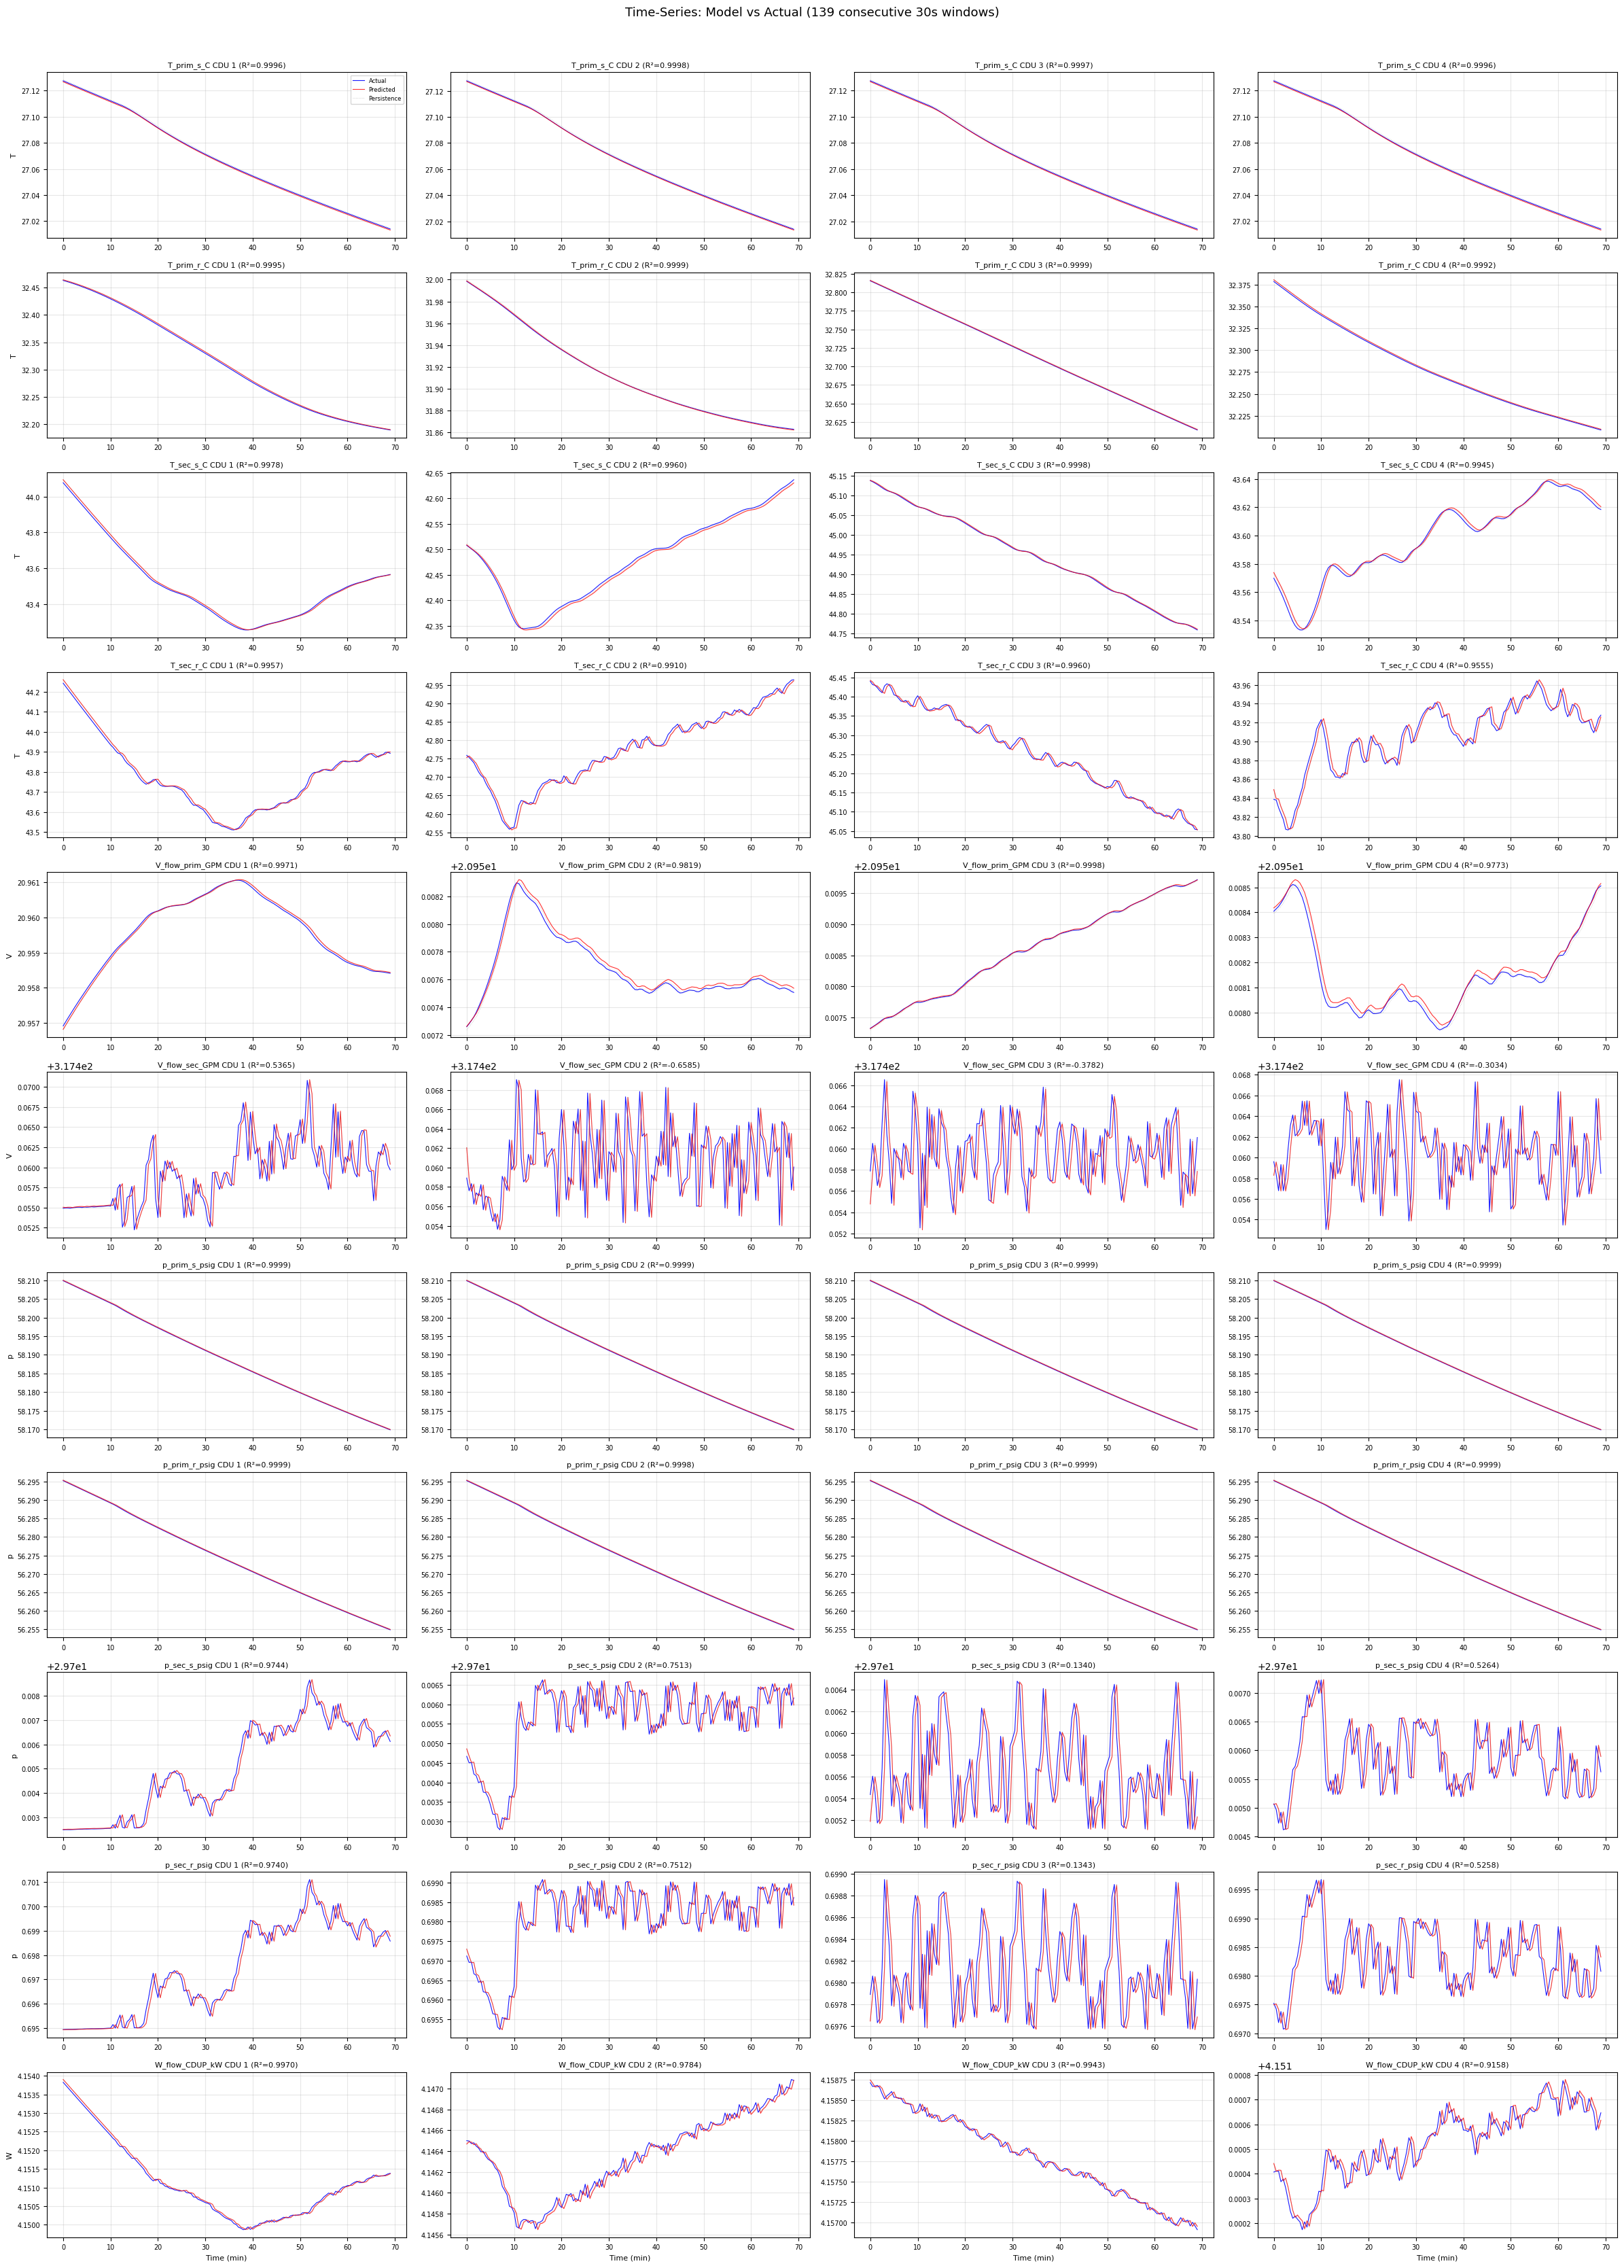

In [22]:
#  Time-Series Predictions — Chain consecutive prediction windows

def plot_timeseries_predictions(predictions_dict, column_info, config,
                                 n_cdus=4, n_samples_show=200):
    """
    Chain consecutive prediction windows into a continuous time-series
    for every output type × selected CDUs.
    """
    pred = predictions_dict['pred_absolute']      # (N, K, n_outputs)
    target = predictions_dict['target_absolute']   # (N, K, n_outputs)
    last_out = predictions_dict['last_output']     # (N, n_outputs)
    output_cols = column_info['output_cols']

    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR   # seconds per step

    N = min(n_samples_show, pred.shape[0])
    cdu_ids = config.CDU_IDS[:n_cdus]

    output_types = config.OUTPUT_NAMES
    n_types = len(output_types)

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.0 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(output_types):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            idx = output_cols.index(col_name)

            # Build time-series from consecutive prediction windows
            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_out[i, idx])

            t_min = np.array(t_vals) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Compute R² for this specific output
            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id} (R²={r2:.4f})', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type.split('_')[0], fontsize=8)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Time-Series: Model vs Actual ({N} consecutive {K*dt}s windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_1_vis/timeseries_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_predictions(predictions_dict, column_info, config)

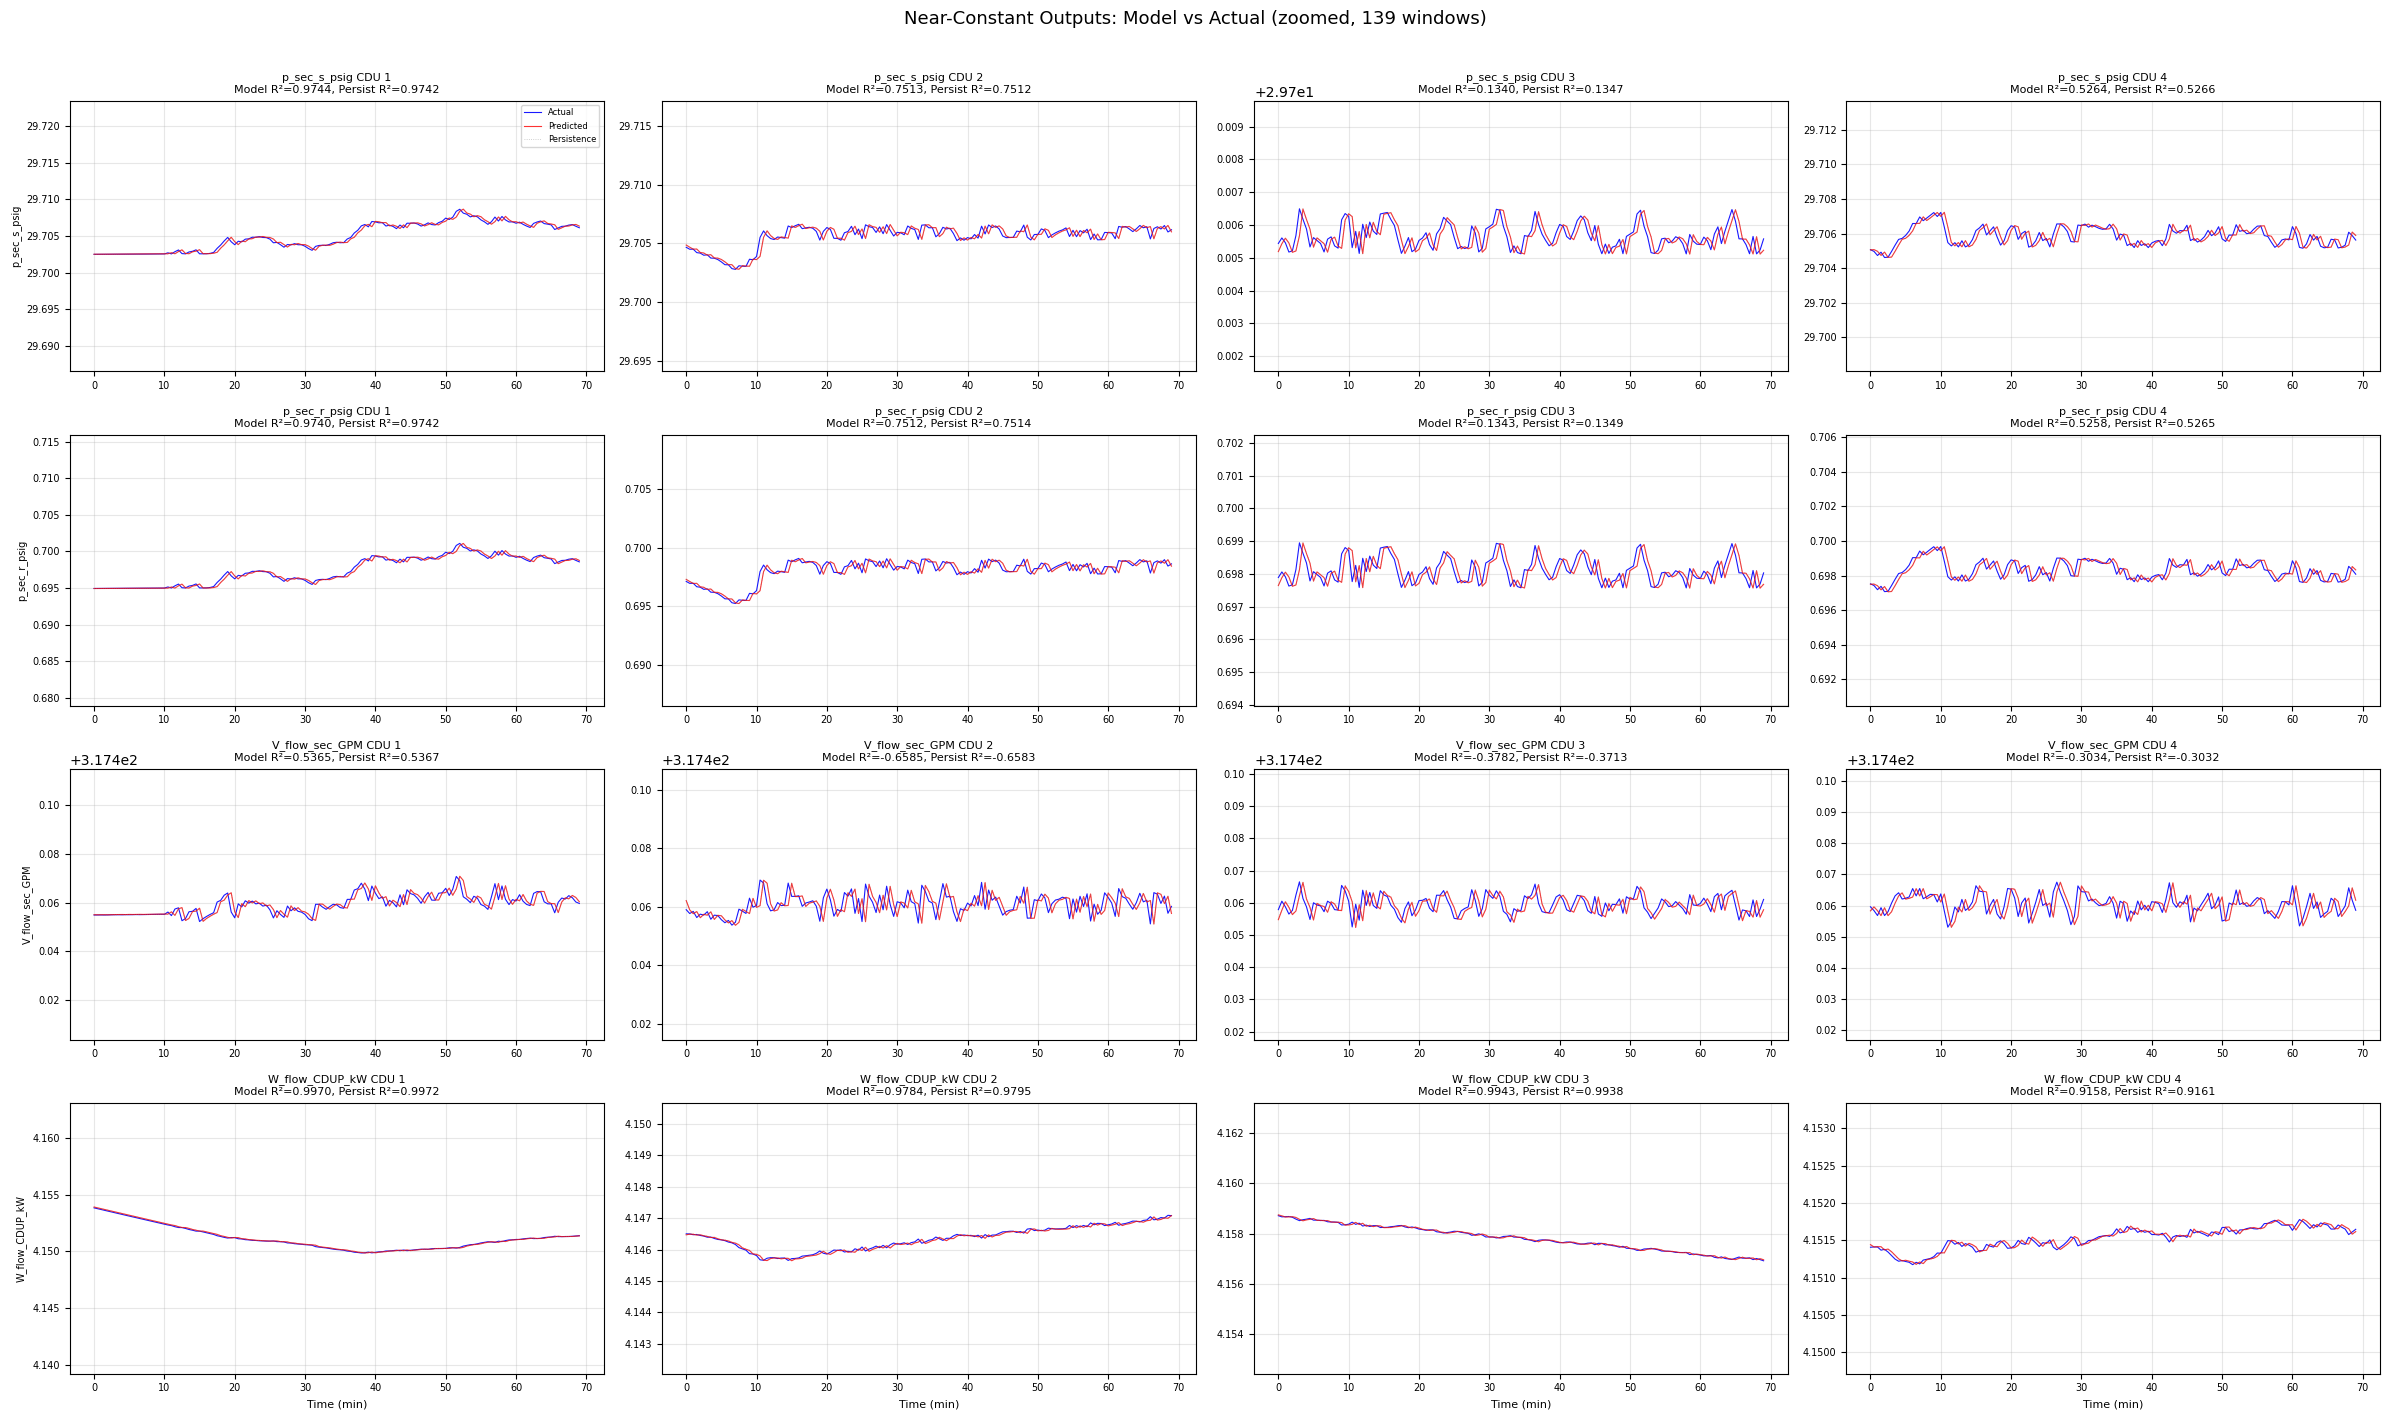

In [23]:
#  Near-Constant Output Time-Series (Zoomed)

def plot_timeseries_nearconst(predictions_dict, column_info, config,
                               n_cdus=4, n_samples_show=200):
    """
    Dedicated time-series for near-constant outputs (Category D, E).
    Y-axis zoomed to ±3× data range for visibility of tiny fluctuations.
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_out = predictions_dict['last_output']
    output_cols = column_info['output_cols']

    nearconst_types = config.CATEGORY_D + config.CATEGORY_E
    n_types = len(nearconst_types)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR
    N = min(n_samples_show, pred.shape[0])

    cdu_ids = config.CDU_IDS[:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.5 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(nearconst_types):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in output_cols:
                ax.set_visible(False)
                continue
            idx = output_cols.index(col_name)

            t_vals, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_vals.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_out[i, idx])

            t_min = np.array(t_vals) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Zoom to ±3× range for visibility
            y_mean = y_actual.mean()
            y_range = max(y_actual.max() - y_actual.min(), 1e-4)
            margin = y_range * 3
            ax.set_ylim(y_mean - margin, y_mean + margin)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ss_res_p = np.sum((y_actual - y_persist) ** 2)
            r2_p = 1 - ss_res_p / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id}\nModel R²={r2:.4f}, '
                         f'Persist R²={r2_p:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type, fontsize=7)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Near-Constant Outputs: Model vs Actual (zoomed, {N} windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_1_vis/timeseries_nearconst.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_nearconst(predictions_dict, column_info, config)

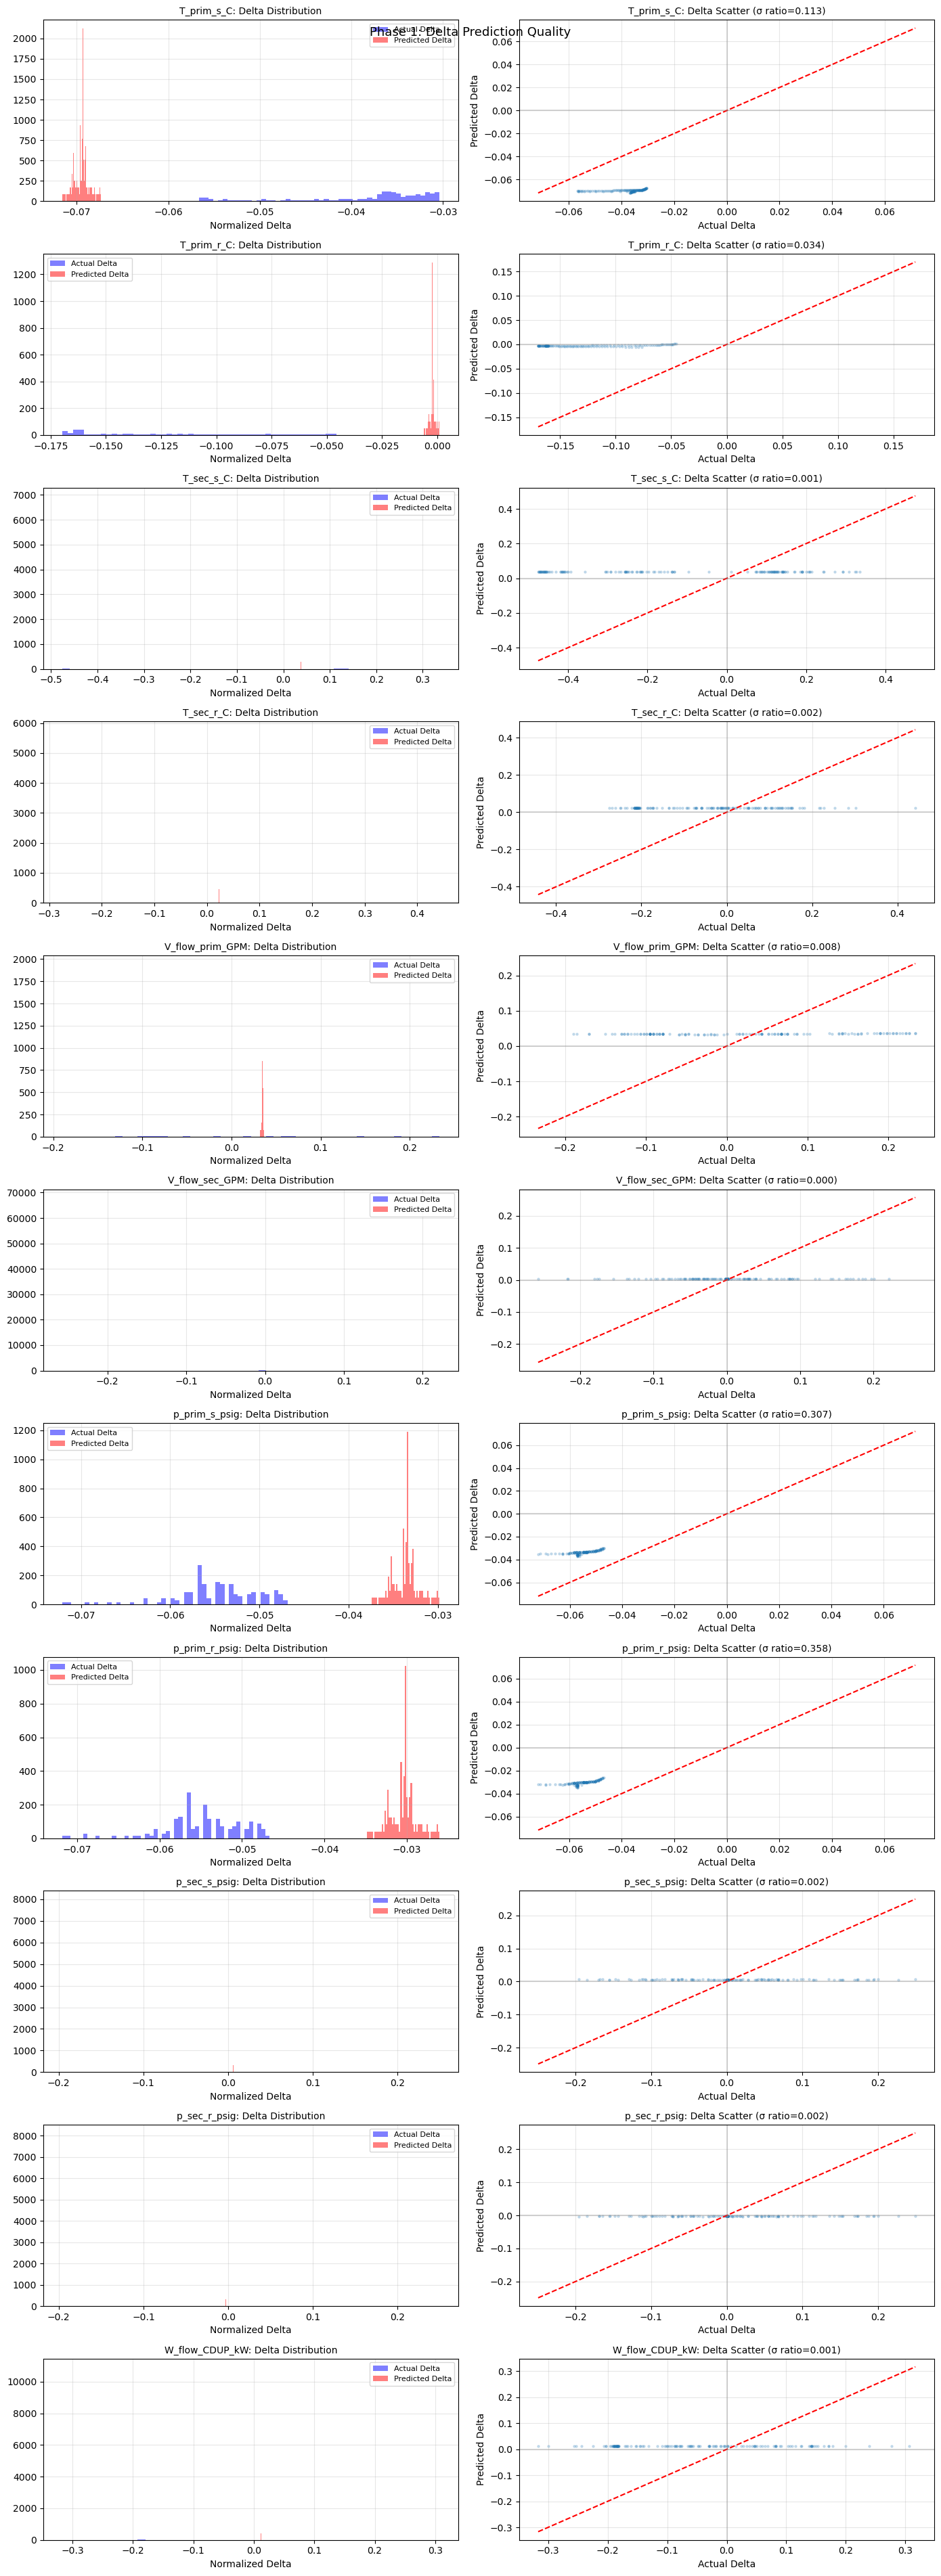

In [24]:
#  Visualization 8 — Delta Prediction Quality

def plot_delta_quality(predictions_dict, column_info, config):
    """Visualize delta prediction quality: std ratio and distribution."""
    pred_norm = predictions_dict['pred_normalized']
    target_norm = predictions_dict['target_normalized']
    output_cols = column_info['output_cols']

    # Select one column per output type
    type_examples = {}
    for col_idx, col in enumerate(output_cols):
        otype = column_info['col_to_type'].get(col)
        if otype not in type_examples:
            type_examples[otype] = col_idx

    n_types = len(type_examples)
    fig, axes = plt.subplots(n_types, 2, figsize=(14, 3.5 * n_types))
    if n_types == 1:
        axes = axes.reshape(1, -1)

    for row, (otype, col_idx) in enumerate(type_examples.items()):
        pred_d = pred_norm[:, 0, col_idx]  # First step
        true_d = target_norm[:, 0, col_idx]

        # Histogram
        ax = axes[row, 0]
        ax.hist(true_d, bins=50, alpha=0.5, label='Actual Delta', density=True, color='blue')
        ax.hist(pred_d, bins=50, alpha=0.5, label='Predicted Delta', density=True, color='red')
        ax.set_title(f'{otype}: Delta Distribution', fontsize=10)
        ax.set_xlabel('Normalized Delta')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # Scatter
        ax = axes[row, 1]
        n_plot = min(3000, len(pred_d))
        plot_idx = np.random.choice(len(pred_d), n_plot, replace=False)
        ax.scatter(true_d[plot_idx], pred_d[plot_idx], alpha=0.2, s=5)
        lim = max(np.abs(true_d).max(), np.abs(pred_d).max())
        ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

        std_ratio = np.std(pred_d) / (np.std(true_d) + 1e-10)
        ax.set_title(f'{otype}: Delta Scatter (σ ratio={std_ratio:.3f})', fontsize=10)
        ax.set_xlabel('Actual Delta')
        ax.set_ylabel('Predicted Delta')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Phase 1: Delta Prediction Quality', fontsize=13)
    plt.tight_layout()
    plt.savefig('phase_1_vis/delta_quality.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_delta_quality(predictions_dict, column_info, config)

## Save Results

In [25]:
#  Save Model, Metrics, and Training History

save_dir = Path('./saved_models/phase1_baseline_lstm')
save_dir.mkdir(parents=True, exist_ok=True)

# Save model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': {
        'HIDDEN_SIZE': config.HIDDEN_SIZE,
        'NUM_LAYERS': config.NUM_LAYERS,
        'DROPOUT': config.DROPOUT,
        'HISTORY_STEPS': config.HISTORY_STEPS,
        'PREDICTION_STEPS': config.PREDICTION_STEPS,
        'SUBSAMPLE_FACTOR': config.SUBSAMPLE_FACTOR,
        'n_inputs': n_inputs,
        'n_outputs': n_outputs,
        'total_input_size': total_input_size,
    },
    'training': {
        'epochs': n_epochs_trained,
        'best_val_loss': early_stopping.best_loss,
        'training_time_sec': train_time,
        'total_params': total_params,
    },
}
torch.save(checkpoint, save_dir / 'phase1_lstm_best.pth')
print(f"Model saved to: {save_dir / 'phase1_lstm_best.pth'}")

# Save metrics
metrics_df.to_csv(save_dir / 'metrics.csv', index=False)
print(f"Metrics saved to: {save_dir / 'metrics.csv'}")

# Save training history
with open(save_dir / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)
print(f"Training history saved to: {save_dir / 'training_history.json'}")

Model saved to: saved_models/phase1_baseline_lstm/phase1_lstm_best.pth
Metrics saved to: saved_models/phase1_baseline_lstm/metrics.csv
Training history saved to: saved_models/phase1_baseline_lstm/training_history.json


In [26]:
#  Final Summary

print("\n" + "=" * 70)
print("PHASE 1: BASELINE LSTM — FINAL SUMMARY")
print("=" * 70)

print(f"\nArchitecture:")
print(f"  Input projection → 2-layer LSTM (128) → Temporal Attention → MLP Decoder")
print(f"  Total parameters: {total_params:,}")
print(f"  Prediction mode:  delta (change from last known value)")

print(f"\nTraining:")
print(f"  Loss:             Huber (δ={config.HUBER_DELTA})")
print(f"  Optimizer:        AdamW (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"  Scheduler:        Cosine annealing (T₀=20, T_mult=2)")
print(f"  Epochs:           {n_epochs_trained} (patience {config.PATIENCE})")
print(f"  Training time:    {train_time:.0f}s")

print(f"\nData:")
print(f"  History:          {config.HISTORY_SECONDS}s ({config.HISTORY_STEPS} steps)")
print(f"  Prediction:       {config.PREDICTION_SECONDS}s ({config.PREDICTION_STEPS} steps)")
print(f"  CDUs:             {config.NUM_CDUS}")
print(f"  Total outputs:    {len(metrics_df)}")

print(f"\nPerformance (Test Set):")
print(f"  Mean R²:          {metrics_df['R²'].mean():.4f}")
print(f"  Median R²:        {metrics_df['R²'].median():.4f}")
print(f"  Outputs R² > 0.8: {(metrics_df['R²'] > 0.8).sum()}/{len(metrics_df)}")
print(f"  Variance Ratio:   {metrics_df['Variance_Ratio'].mean():.2%}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)}")

print(f"\nPer-Category Performance:")
for cat in ['A (Primary loop)', 'B (Secondary temp)', 'C (Primary flow)',
            'D (Secondary pressure)', 'E (Constant)']:
    cat_df = metrics_df[metrics_df['Category'] == cat]
    if len(cat_df) == 0:
        continue
    r2_mean = cat_df['R²'].mean()
    status = 'Excellent' if r2_mean > 0.9 else ('Good' if r2_mean > 0.7 else ('Fair' if r2_mean > 0.3 else 'Poor'))
    print(f"  {cat}: Mean R²={r2_mean:.4f} ({status}, {len(cat_df)} outputs)")

print(f"\nInference:")
print(f"  Total time:       {inference_time:.2f}s")
print(f"  Per sample:       {inference_time/n_test_samples*1000:.2f} ms")


PHASE 1: BASELINE LSTM — FINAL SUMMARY

Architecture:
  Input projection → 2-layer LSTM (128) → Temporal Attention → MLP Decoder
  Total parameters: 1,132,044
  Prediction mode:  delta (change from last known value)

Training:
  Loss:             Huber (δ=0.5)
  Optimizer:        AdamW (lr=0.001, wd=0.0001)
  Scheduler:        Cosine annealing (T₀=20, T_mult=2)
  Epochs:           25 (patience 20)
  Training time:    51s

Data:
  History:          1200s (40 steps)
  Prediction:       30s (1 steps)
  CDUs:             257
  Total outputs:    2827

Performance (Test Set):
  Mean R²:          0.8336
  Median R²:        0.9979
  Outputs R² > 0.8: 2322/2827
  Variance Ratio:   100.26%
  Beats Persistence: 1531/2827

Per-Category Performance:
  A (Primary loop): Mean R²=0.9994 (Excellent, 1028 outputs)
  B (Secondary temp): Mean R²=0.9871 (Excellent, 514 outputs)
  C (Primary flow): Mean R²=0.9974 (Excellent, 257 outputs)
  D (Secondary pressure): Mean R²=0.6771 (Fair, 514 outputs)
  E (Con